# Personal Finance Health Predictor - Data Preprocessing

This notebook handles data cleaning, feature engineering, and preprocessing for all datasets.

# Data Setup

Importing Libraries and Data Sets

In [2]:
# Setup: Set working directory to project root
import os
import sys
from pathlib import Path

# Get the project root directory (parent of notebooks folder)
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    project_root = notebook_dir.parent
    os.chdir(project_root)
    print(f"✓ Working directory set to: {os.getcwd()}")
elif (notebook_dir / 'notebooks').exists():
    project_root = notebook_dir
    print(f"✓ Working directory: {os.getcwd()}")
else:
    current = notebook_dir
    while current != current.parent:
        if (current / 'data').exists() or (current / 'notebooks').exists():
            project_root = current
            os.chdir(project_root)
            print(f"✓ Working directory set to: {os.getcwd()}")
            break
        current = current.parent
    else:
        print(f"⚠ Warning: Could not find project root. Current directory: {os.getcwd()}")

✓ Working directory: e:\personal-finance-health-predictor


In [3]:
# Verify working directory and data files
print(f"Current working directory: {os.getcwd()}")
print(f"Data directory exists: {os.path.exists('data/raw')}")

Current working directory: e:\personal-finance-health-predictor
Data directory exists: True


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

german_credit = pd.read_csv('data/raw/german_credit_data.csv')
lending_club = pd.read_csv('data/raw/accepted/accepted_2007_to_2018Q4.csv',nrows=100000, low_memory=False)
fraud_data = pd.read_csv('data/raw/creditcard.csv')

# Missing Data Analysis

German Credit Dataset


 Columns with Missing Data:
          Column  Missing_Count  Missing_Percentage Data_Type
Checking account            394                39.4    object
 Saving accounts            183                18.3    object


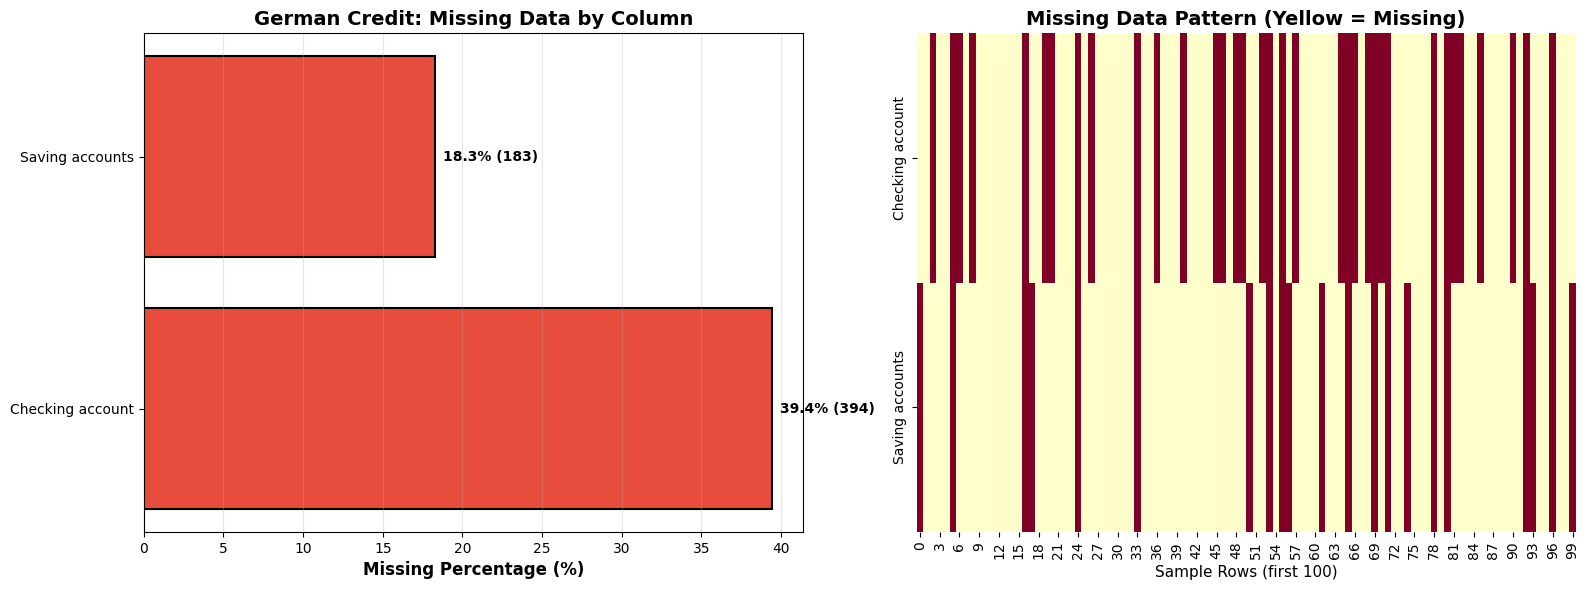


 Summary:
   Total rows: 1,000
   Total columns: 10
   Columns with missing data: 2
   Total missing values: 577


In [5]:
# Count missing values
missing_german = german_credit.isnull().sum()
missing_pct_german = (missing_german / len(german_credit)) * 100

# Create summary dataframe
missing_summary_german = pd.DataFrame({
    'Column': missing_german.index,
    'Missing_Count': missing_german.values,
    'Missing_Percentage': missing_pct_german.values,
    'Data_Type': german_credit.dtypes.values
}).sort_values('Missing_Percentage', ascending=False)

# Display only columns with missing data
missing_cols_german = missing_summary_german[missing_summary_german['Missing_Count'] > 0]

if len(missing_cols_german) > 0:
    print("\n Columns with Missing Data:")
    print(missing_cols_german.to_string(index=False))

    # Visualize missing data
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart
    axes[0].barh(missing_cols_german['Column'], missing_cols_german['Missing_Percentage'],
                 color='#e74c3c', edgecolor='black', linewidth=1.5)
    axes[0].set_xlabel('Missing Percentage (%)', fontsize=12, fontweight='bold')
    axes[0].set_title('German Credit: Missing Data by Column', fontsize=14, fontweight='bold')
    axes[0].grid(alpha=0.3, axis='x')

    # Add value labels
    for i, (col, pct, count) in enumerate(zip(missing_cols_german['Column'],
                                               missing_cols_german['Missing_Percentage'],
                                               missing_cols_german['Missing_Count'])):
        axes[0].text(pct + 0.5, i, f'{pct:.1f}% ({int(count)})',
                    va='center', fontweight='bold', fontsize=10)

    # Heatmap showing pattern
    axes[1].set_title('Missing Data Pattern (Yellow = Missing)', fontsize=14, fontweight='bold')
    missing_matrix = german_credit[missing_cols_german['Column']].isnull()
    sns.heatmap(missing_matrix.head(100).T, cmap='YlOrRd', cbar=False,
                yticklabels=missing_cols_german['Column'], ax=axes[1])
    axes[1].set_xlabel('Sample Rows (first 100)', fontsize=11)

    plt.tight_layout()
    os.makedirs('results/preprocessing', exist_ok=True)
    plt.savefig('results/preprocessing/day2_01_german_missing_data.png', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("\n✅ No missing data found in German Credit dataset!")

# Summary statistics
print(f"\n Summary:")
print(f"   Total rows: {len(german_credit):,}")
print(f"   Total columns: {len(german_credit.columns)}")
print(f"   Columns with missing data: {len(missing_cols_german)}")
print(f"   Total missing values: {missing_german.sum():,}")

Lending Club Dataset


 Top 20 Columns with Missing Data (out of 20 total):
                                    Column  Missing_Count  Missing_Percentage Data_Type
                       sec_app_open_act_il         100000             100.000   float64
                                 member_id         100000             100.000   float64
                           revol_bal_joint         100000             100.000   float64
                    sec_app_fico_range_low         100000             100.000   float64
                   sec_app_fico_range_high         100000             100.000   float64
                  sec_app_earliest_cr_line         100000             100.000   float64
                    sec_app_inq_last_6mths         100000             100.000   float64
                          sec_app_mort_acc         100000             100.000   float64
                          sec_app_open_acc         100000             100.000   float64
                        sec_app_revol_util         100000         

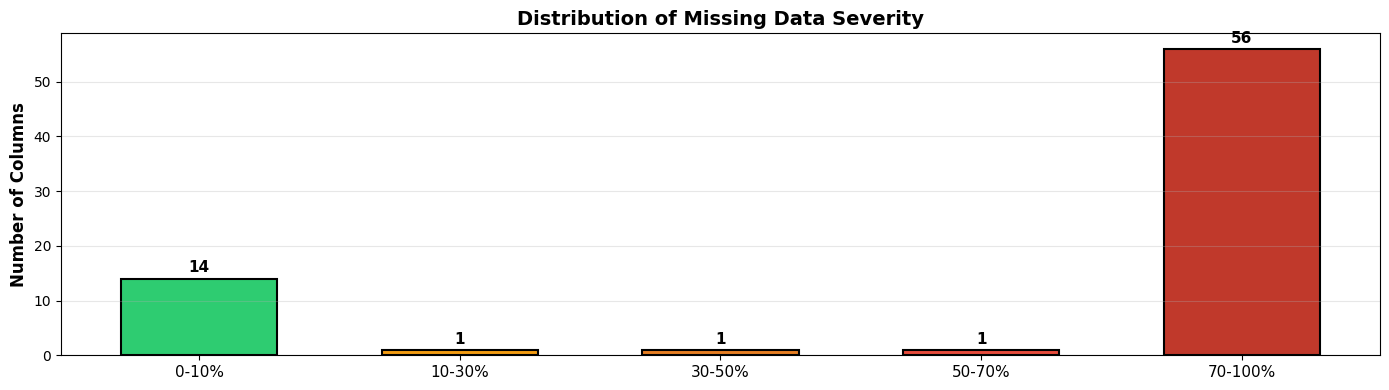


 Summary:
   Total rows: 100,000
   Total columns: 151
   Columns with missing data: 73
   Total missing values: 5,336,952
   Overall missing rate: 35.34%


In [6]:
# Count missing values
missing_lending = lending_club.isnull().sum()
missing_pct_lending = (missing_lending / len(lending_club)) * 100

# Create summary dataframe
missing_summary_lending = pd.DataFrame({
    'Column': missing_lending.index,
    'Missing_Count': missing_lending.values,
    'Missing_Percentage': missing_pct_lending.values,
    'Data_Type': lending_club.dtypes.values
}).sort_values('Missing_Percentage', ascending=False)

# Display top 20 columns with most missing data
missing_cols_lending = missing_summary_lending[missing_summary_lending['Missing_Count'] > 0].head(20)

print(f"\n Top 20 Columns with Missing Data (out of {len(missing_cols_lending)} total):")
print(missing_cols_lending.to_string(index=False))

# Visualize missing data
fig, axes = plt.subplots(1, 1, figsize=(14, 4))

# Missing data by percentage category
missing_categories = pd.cut(missing_summary_lending['Missing_Percentage'],
                            bins=[0, 10, 30, 50, 70, 100],
                            labels=['0-10%', '10-30%', '30-50%', '50-70%', '70-100%'])
category_counts = missing_categories.value_counts().sort_index()

colors_cat = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
axes.bar(range(len(category_counts)), category_counts.values,
            color=colors_cat, edgecolor='black', linewidth=1.5, width=0.6)
axes.set_xticks(range(len(category_counts)))
axes.set_xticklabels(category_counts.index, fontsize=11)
axes.set_ylabel('Number of Columns', fontsize=12, fontweight='bold')
axes.set_title('Distribution of Missing Data Severity', fontsize=14, fontweight='bold')
axes.grid(alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(category_counts.values):
    axes.text(i, v + max(category_counts)*0.02, str(v),
                ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
os.makedirs('results/preprocessing', exist_ok=True)
plt.savefig('results/preprocessing/day2_02_lending_missing_data.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
total_missing_cols = (missing_lending > 0).sum()
print(f"\n Summary:")
print(f"   Total rows: {len(lending_club):,}")
print(f"   Total columns: {len(lending_club.columns)}")
print(f"   Columns with missing data: {total_missing_cols}")
print(f"   Total missing values: {missing_lending.sum():,}")
print(f"   Overall missing rate: {(missing_lending.sum() / (len(lending_club) * len(lending_club.columns))) * 100:.2f}%")

Fraud Dataset

In [7]:

# Count missing values
missing_fraud = fraud_data.isnull().sum()
missing_pct_fraud = (missing_fraud / len(fraud_data)) * 100

# Create summary dataframe
missing_summary_fraud = pd.DataFrame({
    'Column': missing_fraud.index,
    'Missing_Count': missing_fraud.values,
    'Missing_Percentage': missing_pct_fraud.values
}).sort_values('Missing_Percentage', ascending=False)

# Display columns with missing data
missing_cols_fraud = missing_summary_fraud[missing_summary_fraud['Missing_Count'] > 0]

if len(missing_cols_fraud) > 0:
    print("\n📊 Columns with Missing Data:")
    print(missing_cols_fraud.to_string(index=False))
else:
    print("\n✅ Perfect! No missing data in Credit Card Fraud dataset!")
    print("   This is expected - transaction data is typically complete.")

print(f"\n📈 Summary:")
print(f"   Total rows: {len(fraud_data):,}")
print(f"   Total columns: {len(fraud_data.columns)}")
print(f"   Total missing values: {missing_fraud.sum():,}")


✅ Perfect! No missing data in Credit Card Fraud dataset!
   This is expected - transaction data is typically complete.

📈 Summary:
   Total rows: 284,807
   Total columns: 31
   Total missing values: 0


Missing Data Strategy

Decision Rules:
1. More than 70% missing → DROP column (not informative)"
2. 30-70% missing → Analyze pattern, impute or drop"
3. Less than 30% missing → Impute (mean/median/mode)"
4. Categorical → Mode or 'Unknown'"
5. Numerical → Median (robust to outliers)"

#  Handle Missing Data

German Credit

In [8]:
# Create a copy to preserve original
german_credit_clean = german_credit.copy()

# Check which columns have missing data
missing_cols = german_credit_clean.columns[german_credit_clean.isnull().any()].tolist()

if len(missing_cols) > 0:
    print(f"\n Processing {len(missing_cols)} columns with missing data...\n")

    for col in missing_cols:
        missing_count = german_credit_clean[col].isnull().sum()
        missing_pct = (missing_count / len(german_credit_clean)) * 100
        dtype = german_credit_clean[col].dtype

        print(f"Column: {col}")
        print(f"   Missing: {missing_count} ({missing_pct:.1f}%)")
        print(f"   Type: {dtype}")

        # Strategy based on percentage and type
        if missing_pct > 70:
            # Drop column
            german_credit_clean = german_credit_clean.drop(columns=[col])
            print(f"   ✓ ACTION: DROPPED (>70% missing)")

        elif dtype in ['object', 'category']:
            # Categorical: fill with mode or 'Unknown'
            if german_credit_clean[col].mode().empty:
                german_credit_clean[col] = german_credit_clean[col].fillna('Unknown')
                print(f"   ✓ ACTION: Filled with 'Unknown'")
            else:
                mode_value = german_credit_clean[col].mode()[0]
                german_credit_clean[col] = german_credit_clean[col].fillna(mode_value)
                print(f"   ✓ ACTION: Filled with mode '{mode_value}'")

        else:
            # Numerical: fill with median
            median_value = german_credit_clean[col].median()
            german_credit_clean[col] = german_credit_clean[col].fillna(median_value)
            print(f"   ✓ ACTION: Filled with median {median_value:.2f}")

        print()

    # Verify no missing data remains
    remaining_missing = german_credit_clean.isnull().sum().sum()
    print(f"✅ German Credit cleaned: {remaining_missing} missing values remaining")

else:
    print("\n✅ No missing data to handle!")

# Show before/after comparison
print(f"\n📊 Before: {german_credit.shape}")
print(f"📊 After:  {german_credit_clean.shape}")


 Processing 2 columns with missing data...

Column: Saving accounts
   Missing: 183 (18.3%)
   Type: object
   ✓ ACTION: Filled with mode 'little'

Column: Checking account
   Missing: 394 (39.4%)
   Type: object
   ✓ ACTION: Filled with mode 'little'

✅ German Credit cleaned: 0 missing values remaining

📊 Before: (1000, 10)
📊 After:  (1000, 10)


Lending Club

In [9]:
# Create a copy
lending_club_clean = lending_club.copy()

print("\n🔧 Strategy for Lending Club:")
print("   Due to large dataset, we'll be selective about which columns to keep\n")

# Step 1: Identify columns to drop (>50% missing or not useful)
missing_pct_all = (lending_club_clean.isnull().sum() / len(lending_club_clean)) * 100
cols_to_drop = missing_pct_all[missing_pct_all > 50].index.tolist()

print(f"📌 Dropping {len(cols_to_drop)} columns with >50% missing data:")
for col in cols_to_drop[:10]:  # Show first 10
    print(f"   • {col}: {missing_pct_all[col]:.1f}% missing")
if len(cols_to_drop) > 10:
    print(f"   ... and {len(cols_to_drop) - 10} more")

lending_club_clean = lending_club_clean.drop(columns=cols_to_drop)

print(f"\n✓ Dropped {len(cols_to_drop)} columns")
print(f"✓ Remaining columns: {len(lending_club_clean.columns)}")

# Step 2: Focus on key columns for modeling
key_columns = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'loan_status', 'purpose', 'dti',
    'delinq_2yrs', 'earliest_cr_line', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc'
]

# Keep only key columns that exist
key_columns_present = [col for col in key_columns if col in lending_club_clean.columns]
lending_club_clean = lending_club_clean[key_columns_present]

print(f"\n✓ Focused on {len(key_columns_present)} key columns for analysis")

# Step 3: Handle remaining missing data in key columns
print(f"\n🔧 Handling missing data in key columns:\n")

for col in lending_club_clean.columns:
    missing_count = lending_club_clean[col].isnull().sum()

    if missing_count > 0:
        missing_pct = (missing_count / len(lending_club_clean)) * 100
        dtype = lending_club_clean[col].dtype

        print(f"Column: {col}")
        print(f"   Missing: {missing_count:,} ({missing_pct:.1f}%)")

        if dtype in ['object', 'category']:
            # Categorical: fill with 'Unknown' or mode
            if col == 'emp_length':
                lending_club_clean[col] = lending_club_clean[col].fillna('Unknown')
                print(f"   ✓ ACTION: Filled with 'Unknown'")
            else:
                mode_value = lending_club_clean[col].mode()[0] if not lending_club_clean[col].mode().empty else 'Unknown'
                lending_club_clean[col] = lending_club_clean[col].fillna(mode_value)
                print(f"   ✓ ACTION: Filled with mode '{mode_value}'")
        else:
            # Numerical: fill with median
            median_value = lending_club_clean[col].median()
            lending_club_clean[col] = lending_club_clean[col].fillna(median_value)
            print(f"   ✓ ACTION: Filled with median {median_value:.2f}")

        print()

# Verify
remaining_missing = lending_club_clean.isnull().sum().sum()
print(f"✅ Lending Club cleaned: {remaining_missing} missing values remaining")

print(f"\n📊 Before: {lending_club.shape}")
print(f"📊 After:  {lending_club_clean.shape}")


🔧 Strategy for Lending Club:
   Due to large dataset, we'll be selective about which columns to keep

📌 Dropping 57 columns with >50% missing data:
   • member_id: 100.0% missing
   • desc: 100.0% missing
   • mths_since_last_record: 82.2% missing
   • next_pymnt_d: 87.9% missing
   • mths_since_last_major_derog: 70.6% missing
   • annual_inc_joint: 99.5% missing
   • dti_joint: 99.5% missing
   • verification_status_joint: 99.5% missing
   • open_acc_6m: 78.6% missing
   • open_act_il: 78.6% missing
   ... and 47 more

✓ Dropped 57 columns
✓ Remaining columns: 94

✓ Focused on 21 key columns for analysis

🔧 Handling missing data in key columns:

Column: emp_length
   Missing: 6,112 (6.1%)
   ✓ ACTION: Filled with 'Unknown'

Column: dti
   Missing: 2 (0.0%)
   ✓ ACTION: Filled with median 18.70

Column: revol_util
   Missing: 37 (0.0%)
   ✓ ACTION: Filled with median 52.40

✅ Lending Club cleaned: 0 missing values remaining

📊 Before: (100000, 151)
📊 After:  (100000, 21)


Fraud Data:

*   No missing data in Credit Card Fraud dataset!
*   Transaction data is complete - ready for modeling!

Summary & Visualization


📊 Processing Summary:
      Dataset  Original Rows  Original Cols  Final Rows  Final Cols  Missing Before  Missing After
German Credit           1000             10        1000          10             577              0
 Lending Club         100000            151      100000          21         5336952              0


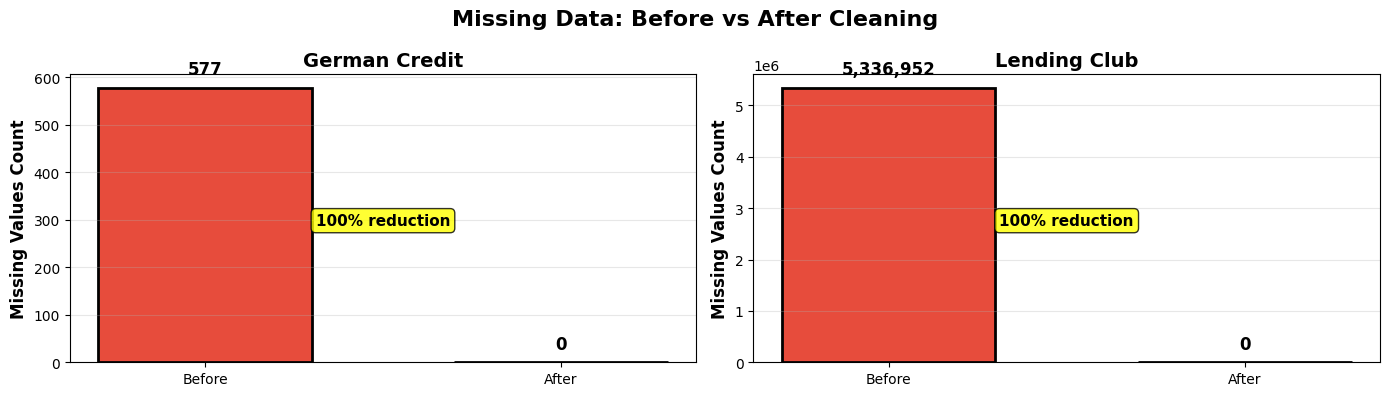


📈 Detailed Metrics:

German Credit:
   • Rows retained: 1,000 / 1,000 (100.0%)
   • Columns retained: 10 / 10
   • Missing values eliminated: 577 → 0

Lending Club:
   • Rows retained: 100,000 / 100,000 (100.0%)
   • Columns retained: 21 / 151
   • Missing values eliminated: 5,336,952 → 0

📁 Cleaned datasets ready for Part 2 (Feature Engineering):
   • german_credit_clean
   • lending_club_clean

💡 Note: Credit Card Fraud dataset had no missing data - already ready for use!


In [10]:
# Create summary table
summary_data = {
    'Dataset': ['German Credit', 'Lending Club'],
    'Original Rows': [len(german_credit), len(lending_club)],
    'Original Cols': [len(german_credit.columns), len(lending_club.columns)],
    'Final Rows': [len(german_credit_clean), len(lending_club_clean)],
    'Final Cols': [len(german_credit_clean.columns), len(lending_club_clean.columns)],
    'Missing Before': [
        german_credit.isnull().sum().sum(),
        lending_club.isnull().sum().sum()
    ],
    'Missing After': [
        german_credit_clean.isnull().sum().sum(),
        lending_club_clean.isnull().sum().sum()
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n📊 Processing Summary:")
print(summary_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Missing Data: Before vs After Cleaning', fontsize=16, fontweight='bold')

datasets = ['German Credit', 'Lending Club']
before = summary_df['Missing Before'].values
after = summary_df['Missing After'].values

for idx, (ax, dataset, b, a) in enumerate(zip(axes, datasets, before, after)):
    ax.bar(['Before', 'After'], [b, a], color=['#e74c3c', '#2ecc71'],
           edgecolor='black', linewidth=2, width=0.6)
    ax.set_title(dataset, fontsize=14, fontweight='bold')
    ax.set_ylabel('Missing Values Count', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

    # Add value labels, scaled relative to the current subplot's data
    current_max_val = max(b, a) # Use max of current subplot's before/after values
    ax.text(0, b + current_max_val*0.05, f'{b:,}', ha='center', fontweight='bold', fontsize=12)
    ax.text(1, a + current_max_val*0.05, f'{a:,}', ha='center', fontweight='bold', fontsize=12)

    # Add percentage reduction
    if b > 0:
        reduction = ((b - a) / b * 100)
        # Position reduction text more centrally within the plot area
        y_pos_reduction = current_max_val * 0.5
        ax.text(0.5, y_pos_reduction, f'{reduction:.0f}% reduction',
                ha='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
    else:
        ax.text(0.5, current_max_val * 0.5, 'No missing data',
                ha='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
os.makedirs('results/preprocessing', exist_ok=True)
plt.savefig('results/preprocessing/day2_03_before_after_cleaning.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional metrics table
print("\n📈 Detailed Metrics:")
print(f"\nGerman Credit:")
print(f"   • Rows retained: {len(german_credit_clean):,} / {len(german_credit):,} ({len(german_credit_clean)/len(german_credit)*100:.1f}%)")
print(f"   • Columns retained: {len(german_credit_clean.columns)} / {len(german_credit.columns)}")
print(f"   • Missing values eliminated: {german_credit.isnull().sum().sum():,} → {german_credit_clean.isnull().sum().sum()}")

print(f"\nLending Club:")
print(f"   • Rows retained: {len(lending_club_clean):,} / {len(lending_club):,} ({len(lending_club_clean)/len(lending_club)*100:.1f}%)")
print(f"   • Columns retained: {len(lending_club_clean.columns)} / {len(lending_club.columns)}")
print(f"   • Missing values eliminated: {lending_club.isnull().sum().sum():,} → {lending_club_clean.isnull().sum().sum()}")


print("\n📁 Cleaned datasets ready for Part 2 (Feature Engineering):")
print("   • german_credit_clean")
print("   • lending_club_clean")
print("\n💡 Note: Credit Card Fraud dataset had no missing data - already ready for use!")

Saving cleaned dataset

In [11]:
german_credit_clean.to_csv('data/processed/german_credit_step1.csv', index=False)
lending_club_clean.to_csv('data/processed/lending_club_step1.csv', index=False)

# Feature Engineering

German Credit

In [12]:
# Create a copy to work with
german_credit_fe = german_credit_clean.copy()

print("AGE_GROUP feature...")

german_credit_fe['age_group'] = pd.cut(
    german_credit_fe['Age'],
    bins=[0, 25, 35, 50, 100],
    labels=['Young_Adult', 'Middle_Age', 'Mature', 'Senior']
)
print("")
print("   ✓ Created age_group")
print("")
print("Distribution:")
print(german_credit_fe['age_group'].value_counts().to_string())

AGE_GROUP feature...

   ✓ Created age_group

Distribution:
age_group
Middle_Age     398
Mature         299
Young_Adult    190
Senior         113


In [13]:
print("CREDIT_CATEGORY feature...")

german_credit_fe['credit_category'] = pd.cut(
    german_credit_fe['Credit amount'],
    bins=[0, 2000, 5000, 10000, 100000],
    labels=['Small', 'Medium', 'Large', 'Very_Large']
)
print("")
print("   ✓ Created credit_category")
print("")
print("Distribution:")
print(german_credit_fe['credit_category'].value_counts().to_string())

CREDIT_CATEGORY feature...

   ✓ Created credit_category

Distribution:
credit_category
Small         432
Medium        380
Large         148
Very_Large     40


In [14]:
print("MONTHLY_PAYMENT feature...")

german_credit_fe['monthly_payment'] = german_credit_fe['Credit amount'] / german_credit_fe['Duration']

print(f"✓ Created monthly_payment")
print("")
print(f"Statistics:")
print("")
print(f"Mean: €{german_credit_fe['monthly_payment'].mean():.2f}")
print(f"Median: €{german_credit_fe['monthly_payment'].median():.2f}")
print(f"Max: €{german_credit_fe['monthly_payment'].max():.2f}")

MONTHLY_PAYMENT feature...
✓ Created monthly_payment

Statistics:

Mean: €167.69
Median: €130.33
Max: €2482.67


In [15]:
print("DURATION_CATEGORY feature...")

german_credit_fe['duration_category'] = pd.cut(
    german_credit_fe['Duration'],
    bins=[0, 12, 24, 36, 100],
    labels=['Short_Term', 'Medium_Term', 'Long_Term', 'Very_Long']
)
print("")
print("✓ Created duration_category")
print("")
print("Distribution:")
print(german_credit_fe['duration_category'].value_counts().to_string())

DURATION_CATEGORY feature...

✓ Created duration_category

Distribution:
duration_category
Medium_Term    411
Short_Term     359
Long_Term      143
Very_Long       87


In [16]:
print("HIGH_VALUE_LOAN feature...")

# High value = top 25% of loan amounts
high_value_threshold = german_credit_fe['Credit amount'].quantile(0.75)
german_credit_fe['high_value_loan'] = (german_credit_fe['Credit amount'] > high_value_threshold).astype(int)

print("")
print(f"✓ Created high_value_loan (1 if amount > €{high_value_threshold:.0f})")
print("")
print(f"High value loans: {german_credit_fe['high_value_loan'].sum()} ({german_credit_fe['high_value_loan'].mean()*100:.1f}%)")

HIGH_VALUE_LOAN feature...

✓ Created high_value_loan (1 if amount > €3972)

High value loans: 250 (25.0%)


In [17]:
print("Creating AGE_TO_DURATION_RATIO feature...")

german_credit_fe['age_to_duration_ratio'] = german_credit_fe['Age'] / german_credit_fe['Duration']

print("")
print(f"✓ Created age_to_duration_ratio")
print("")
print(f"Interpretation: Higher ratio = older person with shorter loan")
print(f"Mean: {german_credit_fe['age_to_duration_ratio'].mean():.2f}")

Creating AGE_TO_DURATION_RATIO feature...

✓ Created age_to_duration_ratio

Interpretation: Higher ratio = older person with shorter loan
Mean: 2.41


In [18]:
print("Creating PURPOSE_RISK_LEVEL feature...")

# Based on typical default rates by purpose (domain knowledge)
purpose_risk_map = {
    'car': 'Medium',
    'radio/TV': 'Low',
    'furniture/equipment': 'Medium',
    'business': 'High',
    'education': 'Medium',
    'repairs': 'Low',
    'domestic appliances': 'Low',
    'vacation/others': 'High',
    'retraining': 'Medium'
}

german_credit_fe['purpose_risk_level'] = german_credit_fe['Purpose'].map(purpose_risk_map)
# Fill any unmapped values with 'Medium'
german_credit_fe['purpose_risk_level'] = german_credit_fe['purpose_risk_level'].fillna('Medium')

print("")
print(f"✓ Created purpose_risk_level")
print("")
print(f"Distribution:")
print(german_credit_fe['purpose_risk_level'].value_counts().to_string())

Creating PURPOSE_RISK_LEVEL feature...

✓ Created purpose_risk_level

Distribution:
purpose_risk_level
Medium    577
Low       314
High      109


In [19]:
print("\n" + "="*70)
print("GERMAN CREDIT: FEATURE ENGINEERING SUMMARY")
print("="*70)

new_features_german = [
    'age_group', 'credit_category', 'monthly_payment',
    'duration_category', 'high_value_loan', 'age_to_duration_ratio',
    'purpose_risk_level'
]

print(f"\n✅ Created {len(new_features_german)} new features:")
for i, feature in enumerate(new_features_german, 1):
    print(f"   {i}. {feature}")

print(f"\n📊 Dataset size:")
print(f"   Before: {len(german_credit_clean.columns)} columns")
print(f"   After: {len(german_credit_fe.columns)} columns")
print(f"   New features: +{len(german_credit_fe.columns) - len(german_credit_clean.columns)}")


GERMAN CREDIT: FEATURE ENGINEERING SUMMARY

✅ Created 7 new features:
   1. age_group
   2. credit_category
   3. monthly_payment
   4. duration_category
   5. high_value_loan
   6. age_to_duration_ratio
   7. purpose_risk_level

📊 Dataset size:
   Before: 10 columns
   After: 17 columns
   New features: +7


 Lending Club

In [20]:
lending_club_fe = lending_club_clean.copy()

print(f"\n📊 Starting with {len(lending_club_fe.columns)} columns")
print(f"Creating new features...\n")


📊 Starting with 21 columns
Creating new features...



In [21]:
print("LOAN_TO_INCOME_RATIO feature...")

lending_club_fe['loan_to_income_ratio'] = lending_club_fe['loan_amnt'] / lending_club_fe['annual_inc']

# Handle infinite values (division by zero)
lending_club_fe['loan_to_income_ratio'] = lending_club_fe['loan_to_income_ratio'].replace([np.inf, -np.inf], np.nan)
lending_club_fe['loan_to_income_ratio'] = lending_club_fe['loan_to_income_ratio'].fillna(lending_club_fe['loan_to_income_ratio'].median())

print("")
print(f"✓ Created loan_to_income_ratio")
print("")
print(f"Statistics:")
print(f"Mean: {lending_club_fe['loan_to_income_ratio'].mean():.2%}")
print(f"Median: {lending_club_fe['loan_to_income_ratio'].median():.2%}")
print(f"Loans >50% of income: {(lending_club_fe['loan_to_income_ratio'] > 0.5).sum():,}")

LOAN_TO_INCOME_RATIO feature...

✓ Created loan_to_income_ratio

Statistics:
Mean: 21.97%
Median: 20.57%
Loans >50% of income: 114


In [22]:
print("MONTHLY_PAYMENT_BURDEN feature...")

lending_club_fe['monthly_income'] = lending_club_fe['annual_inc'] / 12
lending_club_fe['monthly_payment_burden'] = lending_club_fe['installment'] / lending_club_fe['monthly_income']

# Handle infinite values
lending_club_fe['monthly_payment_burden'] = lending_club_fe['monthly_payment_burden'].replace([np.inf, -np.inf], np.nan)
lending_club_fe['monthly_payment_burden'] = lending_club_fe['monthly_payment_burden'].fillna(lending_club_fe['monthly_payment_burden'].median())

print("")
print(f"✓ Created monthly_payment_burden")
print("")
print(f"Mean burden: {lending_club_fe['monthly_payment_burden'].mean():.2%} of monthly income")
print(f"Payments >30% of income: {(lending_club_fe['monthly_payment_burden'] > 0.3).sum():,}")


MONTHLY_PAYMENT_BURDEN feature...

✓ Created monthly_payment_burden

Mean burden: 7.71% of monthly income
Payments >30% of income: 28


In [23]:
print("Creating DTI_RISK_CATEGORY feature...")

lending_club_fe['dti_risk_category'] = pd.cut(
    lending_club_fe['dti'],
    bins=[0, 10, 20, 30, 100],
    labels=['Low_Risk', 'Moderate_Risk', 'High_Risk', 'Very_High_Risk']
)

print("")
print("✓ Created dti_risk_category")
print("")
print("Distribution:")
print(lending_club_fe['dti_risk_category'].value_counts().to_string())

Creating DTI_RISK_CATEGORY feature...

✓ Created dti_risk_category

Distribution:
dti_risk_category
Moderate_Risk     39330
High_Risk         31742
Low_Risk          15942
Very_High_Risk    12951


In [24]:
print("INTEREST_RATE_CATEGORY feature...")

lending_club_fe['interest_rate_category'] = pd.cut(
    lending_club_fe['int_rate'],
    bins=[0, 8, 12, 16, 100],
    labels=['Low_Rate', 'Medium_Rate', 'High_Rate', 'Very_High_Rate']
)

print("")
print("✓ Created interest_rate_category")
print("")
print("Distribution:")
print(lending_club_fe['interest_rate_category'].value_counts().to_string())

INTEREST_RATE_CATEGORY feature...

✓ Created interest_rate_category

Distribution:
interest_rate_category
Medium_Rate       33605
High_Rate         30101
Very_High_Rate    18758
Low_Rate          17536


In [25]:
print("EMP_LENGTH_YEARS feature...")

def extract_emp_length(emp_str):
    """Extract numerical employment length from string"""
    if pd.isna(emp_str) or emp_str == 'Unknown':
        return np.nan
    if emp_str == '< 1 year':
        return 0.5
    elif emp_str == '10+ years':
        return 10
    else:
        try:
            return float(emp_str.split()[0])
        except:
            return np.nan

lending_club_fe['emp_length_years'] = lending_club_fe['emp_length'].apply(extract_emp_length)
lending_club_fe['emp_length_years'] = lending_club_fe['emp_length_years'].fillna(lending_club_fe['emp_length_years'].median())

# Create categories
lending_club_fe['emp_stability'] = pd.cut(
    lending_club_fe['emp_length_years'],
    bins=[0, 2, 5, 10, 100],
    labels=['New_Employee', 'Stable', 'Experienced', 'Very_Experienced']
)

print("")
print("✓ Created emp_length_years and emp_stability")
print("")
print("Distribution:")
print(lending_club_fe['emp_stability'].value_counts().to_string())

EMP_LENGTH_YEARS feature...

✓ Created emp_length_years and emp_stability

Distribution:
emp_stability
Experienced         56236
New_Employee        23978
Stable              19786
Very_Experienced        0


In [26]:
print("Creating LOAN_STATUS_BINARY feature...")

# Map loan status to binary outcome
status_mapping = {
    'Fully Paid': 0,
    'Current': 0,
    'Charged Off': 1,
    'Default': 1,
    'Late (31-120 days)': 1,
    'Late (16-30 days)': 1,
    'In Grace Period': 0,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1
}

lending_club_fe['loan_status_binary'] = lending_club_fe['loan_status'].map(status_mapping)

# Count how many we successfully mapped
mapped_count = lending_club_fe['loan_status_binary'].notna().sum()

print("")
print("✓ Created loan_status_binary")
print("")
print(f"Mapped {mapped_count:,} / {len(lending_club_fe):,} records")
print(f"Default rate: {lending_club_fe['loan_status_binary'].mean()*100:.2f}%")

Creating LOAN_STATUS_BINARY feature...

✓ Created loan_status_binary

Mapped 100,000 / 100,000 records
Default rate: 18.11%


In [27]:
print("Creating REVOL_UTIL_CATEGORY feature...")

lending_club_fe['revol_util_category'] = pd.cut(
lending_club_fe['revol_util'],
bins=[0, 30, 50, 70, 100],
labels=['Low_Util', 'Medium_Util', 'High_Util', 'Maxed_Out']
)

print("")
print("✓ Created revol_util_category")
print("")
print("Distribution:")
print(lending_club_fe['revol_util_category'].value_counts().to_string())

Creating REVOL_UTIL_CATEGORY feature...

✓ Created revol_util_category

Distribution:
revol_util_category
High_Util      27363
Medium_Util    26940
Maxed_Out      25383
Low_Util       19464


In [28]:
print("Creating TOTAL_PAYMENT_AMOUNT feature...")

# Calculate total amount to be paid over loan term
lending_club_fe['loan_term_months'] = lending_club_fe['term'].str.extract(r'(\d+)').astype(float)
lending_club_fe['total_payment_amount'] = lending_club_fe['installment'] * lending_club_fe['loan_term_months']
lending_club_fe['total_interest_paid'] = lending_club_fe['total_payment_amount'] - lending_club_fe['loan_amnt']

print("")
print("✓ Created total_payment_amount and total_interest_paid")
print("")
print(f"Average interest paid: ${lending_club_fe['total_interest_paid'].mean():,.2f}")

Creating TOTAL_PAYMENT_AMOUNT feature...

✓ Created total_payment_amount and total_interest_paid

Average interest paid: $4,280.71


In [29]:
print("Creating CREDIT_HISTORY_LENGTH feature...")


    # Parse date and calculate years
def calc_credit_history(date_str):
    try:
        date_obj = pd.to_datetime(date_str)
        years = (pd.Timestamp.now() - date_obj).days / 365.25
        return years
    except:
        return np.nan

lending_club_fe['credit_history_years'] = lending_club_fe['earliest_cr_line'].apply(calc_credit_history)
lending_club_fe['credit_history_years'] = lending_club_fe['credit_history_years'].fillna(lending_club_fe['credit_history_years'].median())

print("")
print("✓ Created credit_history_years")
print("")
print(f"Mean history: {lending_club_fe['credit_history_years'].mean():.1f} years")

Creating CREDIT_HISTORY_LENGTH feature...

✓ Created credit_history_years

Mean history: 26.9 years


In [30]:
print("Creating RISK_SCORE composite feature...")

# Create a simple risk score based on multiple factors
# Higher score = higher risk
lending_club_fe['risk_score'] = 0

# Add points for high DTI
lending_club_fe.loc[lending_club_fe['dti'] > 30, 'risk_score'] += 2
lending_club_fe.loc[lending_club_fe['dti'] > 40, 'risk_score'] += 1

# Add points for high interest rate (market sees them as risky)
lending_club_fe.loc[lending_club_fe['int_rate'] > 15, 'risk_score'] += 2
lending_club_fe.loc[lending_club_fe['int_rate'] > 20, 'risk_score'] += 1

# Add points for high loan-to-income
lending_club_fe.loc[lending_club_fe['loan_to_income_ratio'] > 0.3, 'risk_score'] += 1
lending_club_fe.loc[lending_club_fe['loan_to_income_ratio'] > 0.5, 'risk_score'] += 2

# Add points for grade
grade_risk = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
lending_club_fe['grade_risk_points'] = lending_club_fe['grade'].map(grade_risk).fillna(3)
lending_club_fe['risk_score'] += lending_club_fe['grade_risk_points']

print("")
print("✓ Created risk_score (0-12 scale)")
print("")
print("Score distribution:")
print(lending_club_fe['risk_score'].value_counts().sort_index().to_string())

Creating RISK_SCORE composite feature...

✓ Created risk_score (0-12 scale)

Score distribution:
risk_score
0     14935
1     25591
2     23723
3      8136
4      3601
5      8073
6      6281
7      3990
8      3102
9      1823
10      413
11      265
12       49
13        8
14        8
15        2


In [31]:
print("\n" + "="*70)
print("LENDING CLUB: FEATURE ENGINEERING SUMMARY")
print("="*70)

new_features_lending = [
    'loan_to_income_ratio', 'monthly_income', 'monthly_payment_burden',
    'dti_risk_category', 'interest_rate_category', 'emp_length_years',
    'emp_stability', 'loan_status_binary', 'loan_term_months',
    'total_payment_amount', 'total_interest_paid', 'risk_score'
]

# Check which features were actually created
created_features = [f for f in new_features_lending if f in lending_club_fe.columns]

print(f"\n Created {len(created_features)} new features:")
for i, feature in enumerate(created_features, 1):
    print(f"   {i}. {feature}")

print(f"\n Dataset size:")
print(f"   Before: {len(lending_club_clean.columns)} columns")
print(f"   After: {len(lending_club_fe.columns)} columns")
print(f"   New features: +{len(lending_club_fe.columns) - len(lending_club_clean.columns)}")


LENDING CLUB: FEATURE ENGINEERING SUMMARY

 Created 12 new features:
   1. loan_to_income_ratio
   2. monthly_income
   3. monthly_payment_burden
   4. dti_risk_category
   5. interest_rate_category
   6. emp_length_years
   7. emp_stability
   8. loan_status_binary
   9. loan_term_months
   10. total_payment_amount
   11. total_interest_paid
   12. risk_score

 Dataset size:
   Before: 21 columns
   After: 36 columns
   New features: +15


Fraud Data

In [32]:
fraud_data_fe = fraud_data.copy()

print(f"Starting with {len(fraud_data_fe.columns)} columns")
print(f"Creating new features...\n")

Starting with 31 columns
Creating new features...



In [33]:
print("Creating HOUR feature...")

fraud_data_fe['hour'] = (fraud_data_fe['Time'] / 3600) % 24
fraud_data_fe['hour'] = fraud_data_fe['hour'].astype(int)

print("")
print("✓ Created hour (0-23)")
print("")
print(f"Peak transaction hour: {fraud_data_fe['hour'].mode()[0]}:00")

Creating HOUR feature...

✓ Created hour (0-23)

Peak transaction hour: 21:00


In [34]:
print("Creating TIME_OF_DAY feature...")

def categorize_time(hour):
    if 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

fraud_data_fe['time_of_day'] = fraud_data_fe['hour'].apply(categorize_time)

print("")
print("✓ Created time_of_day")
print("")
print("Distribution:")
print(fraud_data_fe['time_of_day'].value_counts().to_string())

Creating TIME_OF_DAY feature...

✓ Created time_of_day

Distribution:
time_of_day
Afternoon    96435
Evening      93526
Morning      70912
Night        23934


In [35]:
print("Creating DAY feature...")

fraud_data_fe['day'] = (fraud_data_fe['Time'] / (3600 * 24)).astype(int)

print("")
print("✓ Created day (transaction day number)")
print("")
print(f"Data spans {fraud_data_fe['day'].max() + 1} days")

Creating DAY feature...

✓ Created day (transaction day number)

Data spans 2 days


In [36]:
print("Creating AMOUNT_CATEGORY feature...")

fraud_data_fe['amount_category'] = pd.cut(
    fraud_data_fe['Amount'],
    bins=[0, 50, 100, 250, 500, 30000],
    labels=['Very_Small', 'Small', 'Medium', 'Large', 'Very_Large']
)

print("")
print("✓ Created amount_category")
print("")
print("Distribution:")
print(fraud_data_fe['amount_category'].value_counts().to_string())

Creating AMOUNT_CATEGORY feature...

✓ Created amount_category

Distribution:
amount_category
Very_Small    189220
Small          37254
Medium         33873
Large          13493
Very_Large      9142


In [37]:
print("Creating AMOUNT_SCALED feature...")

from sklearn.preprocessing import StandardScaler
scaler_amount = StandardScaler()
fraud_data_fe['amount_scaled'] = scaler_amount.fit_transform(fraud_data_fe[['Amount']])

print("")
print("✓ Created amount_scaled")
print("")
print(f"Mean: {fraud_data_fe['amount_scaled'].mean():.3f} (should be ~0)")
print(f"Std: {fraud_data_fe['amount_scaled'].std():.3f} (should be ~1)")

Creating AMOUNT_SCALED feature...



✓ Created amount_scaled

Mean: 0.000 (should be ~0)
Std: 1.000 (should be ~1)


In [38]:
print("Creating HIGH_AMOUNT feature...")

# High amount = top 10% of transactions
high_amount_threshold = fraud_data_fe['Amount'].quantile(0.90)
fraud_data_fe['high_amount'] = (fraud_data_fe['Amount'] > high_amount_threshold).astype(int)

print("")
print(f"✓ Created high_amount (1 if >€{high_amount_threshold:.2f})")
print("")
print(f"High amount transactions: {fraud_data_fe['high_amount'].sum():,} ({fraud_data_fe['high_amount'].mean()*100:.1f}%)")

Creating HIGH_AMOUNT feature...

✓ Created high_amount (1 if >€203.00)

High amount transactions: 28,458 (10.0%)


In [39]:
print("Creating TRANSACTION_FREQUENCY features...")

# Transactions per hour bucket
fraud_data_fe['hour_bucket'] = (fraud_data_fe['Time'] / 3600).astype(int)
hour_counts = fraud_data_fe.groupby('hour_bucket').size()
fraud_data_fe['transactions_in_hour'] = fraud_data_fe['hour_bucket'].map(hour_counts)

print("")
print("✓ Created transactions_in_hour")
print("")
print(f"Mean transactions per hour: {fraud_data_fe['transactions_in_hour'].mean():.0f}")

Creating TRANSACTION_FREQUENCY features...

✓ Created transactions_in_hour

Mean transactions per hour: 7294


In [40]:
print("Creating V_FEATURE_MAGNITUDE feature...")

# Calculate magnitude of V features (similar to vector magnitude)
v_cols = [col for col in fraud_data_fe.columns if col.startswith('V')]
fraud_data_fe['v_feature_magnitude'] = np.sqrt((fraud_data_fe[v_cols] ** 2).sum(axis=1))

print("")
print("✓ Created v_feature_magnitude")
print("")
print(f"Mean magnitude: {fraud_data_fe['v_feature_magnitude'].mean():.2f}")

Creating V_FEATURE_MAGNITUDE feature...

✓ Created v_feature_magnitude

Mean magnitude: 4.78


In [41]:
print("\n" + "="*70)
print("CREDIT CARD FRAUD: FEATURE ENGINEERING SUMMARY")
print("="*70)

new_features_fraud = [
    'hour', 'time_of_day', 'day', 'amount_category',
    'amount_scaled', 'high_amount', 'hour_bucket',
    'transactions_in_hour', 'v_feature_magnitude'
]

print(f"\n✅ Created {len(new_features_fraud)} new features:")
for i, feature in enumerate(new_features_fraud, 1):
    print(f"   {i}. {feature}")

print(f"\n📊 Dataset size:")
print(f"   Before: {len(fraud_data.columns)} columns")
print(f"   After: {len(fraud_data_fe.columns)} columns")
print(f"   New features: +{len(fraud_data_fe.columns) - len(fraud_data.columns)}")


CREDIT CARD FRAUD: FEATURE ENGINEERING SUMMARY

✅ Created 9 new features:
   1. hour
   2. time_of_day
   3. day
   4. amount_category
   5. amount_scaled
   6. high_amount
   7. hour_bucket
   8. transactions_in_hour
   9. v_feature_magnitude

📊 Dataset size:
   Before: 31 columns
   After: 40 columns
   New features: +9


# Visualize New Features

In [42]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

Creating visualizations for German Credit new features

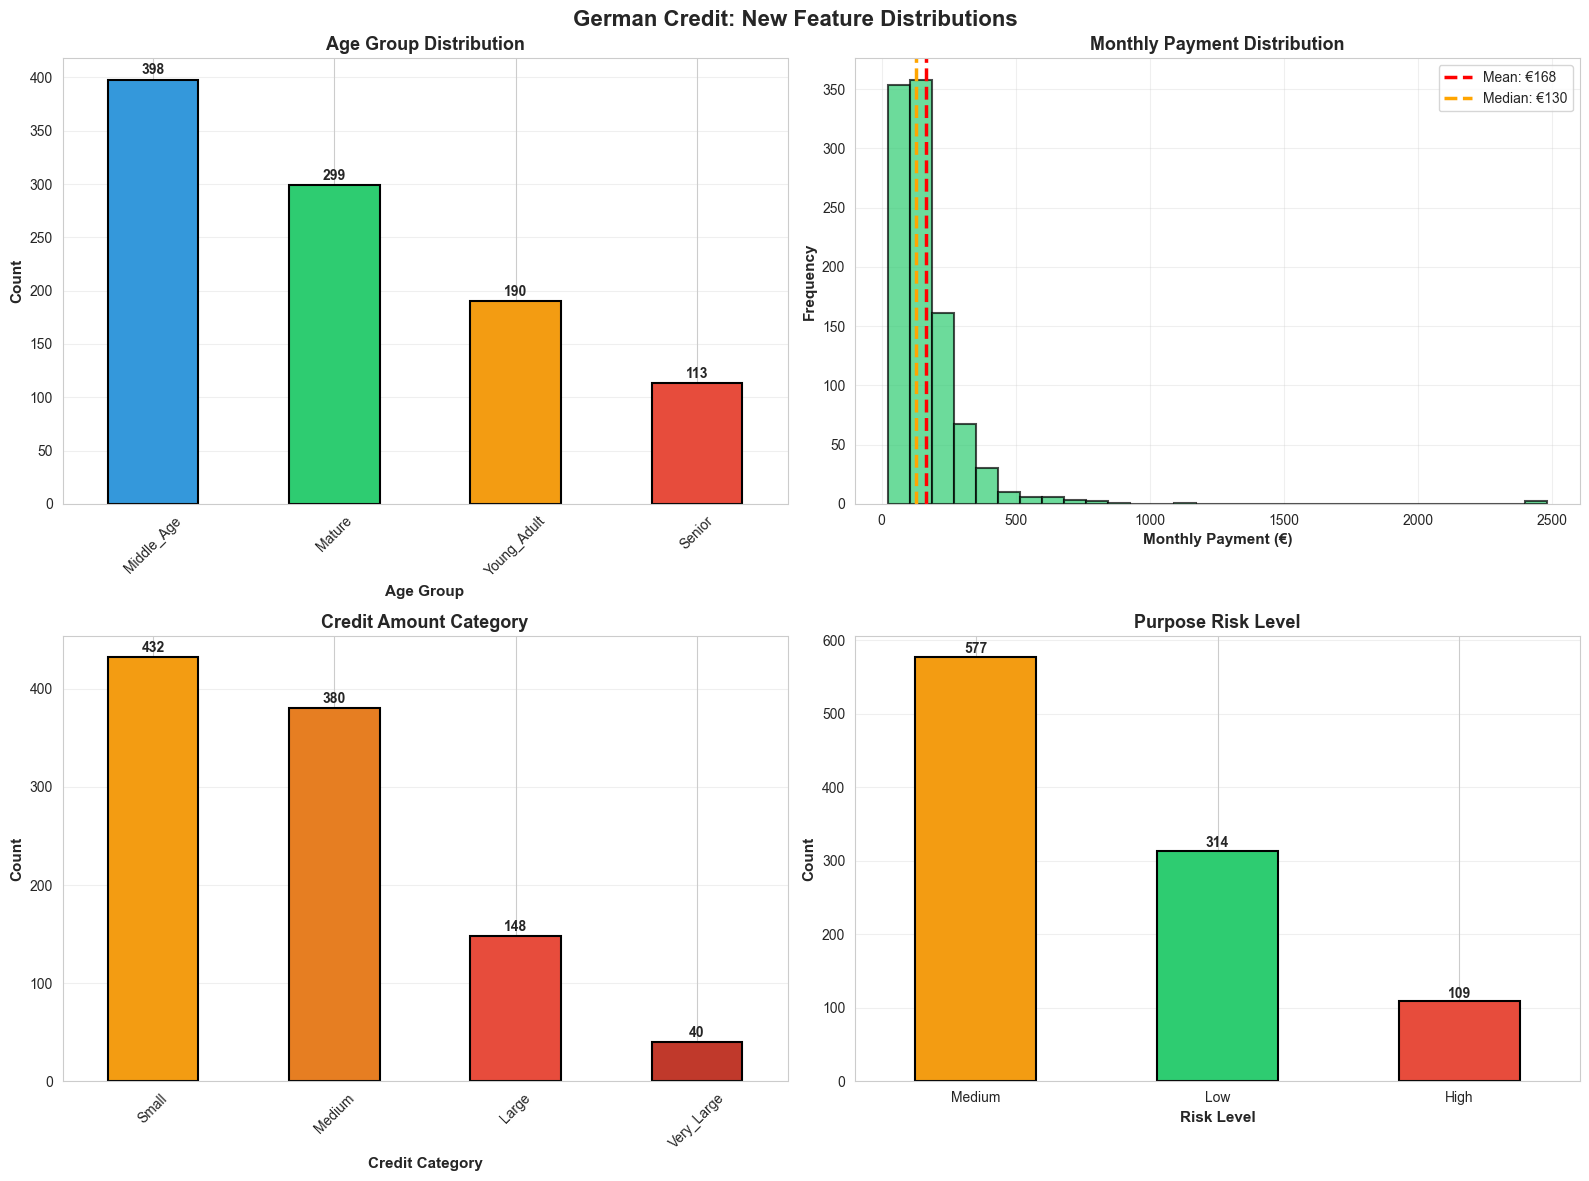

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('German Credit: New Feature Distributions', fontsize=16, fontweight='bold')

# Panel 1: Age Group
age_group_counts = german_credit_fe['age_group'].value_counts()
colors_age = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
age_group_counts.plot(kind='bar', ax=axes[0, 0], color=colors_age, edgecolor='black', linewidth=1.5)
axes[0, 0].set_title('Age Group Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Age Group', fontsize=11, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(age_group_counts.values):
    axes[0, 0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=10)

# Panel 2: Monthly Payment Distribution
axes[0, 1].hist(german_credit_fe['monthly_payment'], bins=30, color='#2ecc71',
                edgecolor='black', alpha=0.7, linewidth=1.5)
mean_payment = german_credit_fe['monthly_payment'].mean()
median_payment = german_credit_fe['monthly_payment'].median()
axes[0, 1].axvline(mean_payment, color='red', linestyle='--', linewidth=2.5,
                   label=f'Mean: €{mean_payment:.0f}')
axes[0, 1].axvline(median_payment, color='orange', linestyle='--', linewidth=2.5,
                   label=f'Median: €{median_payment:.0f}')
axes[0, 1].set_title('Monthly Payment Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Monthly Payment (€)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(alpha=0.3)

# Panel 3: Credit Category
credit_cat_counts = german_credit_fe['credit_category'].value_counts()
colors_credit = ['#f39c12', '#e67e22', '#e74c3c', '#c0392b']
credit_cat_counts.plot(kind='bar', ax=axes[1, 0], color=colors_credit,
                       edgecolor='black', linewidth=1.5)
axes[1, 0].set_title('Credit Amount Category', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Credit Category', fontsize=11, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(credit_cat_counts.values):
    axes[1, 0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=10)

# Panel 4: Purpose Risk Level
risk_counts = german_credit_fe['purpose_risk_level'].value_counts()
risk_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
colors_risk = [risk_colors.get(cat, '#95a5a6') for cat in risk_counts.index]
risk_counts.plot(kind='bar', ax=axes[1, 1], color=colors_risk,
                 edgecolor='black', linewidth=1.5)
axes[1, 1].set_title('Purpose Risk Level', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Risk Level', fontsize=11, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].grid(alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(risk_counts.values):
    axes[1, 1].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
os.makedirs('results/preprocessing', exist_ok=True)
plt.savefig('results/preprocessing/day2_04_german_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

Creating visualizations for Lending Club new features

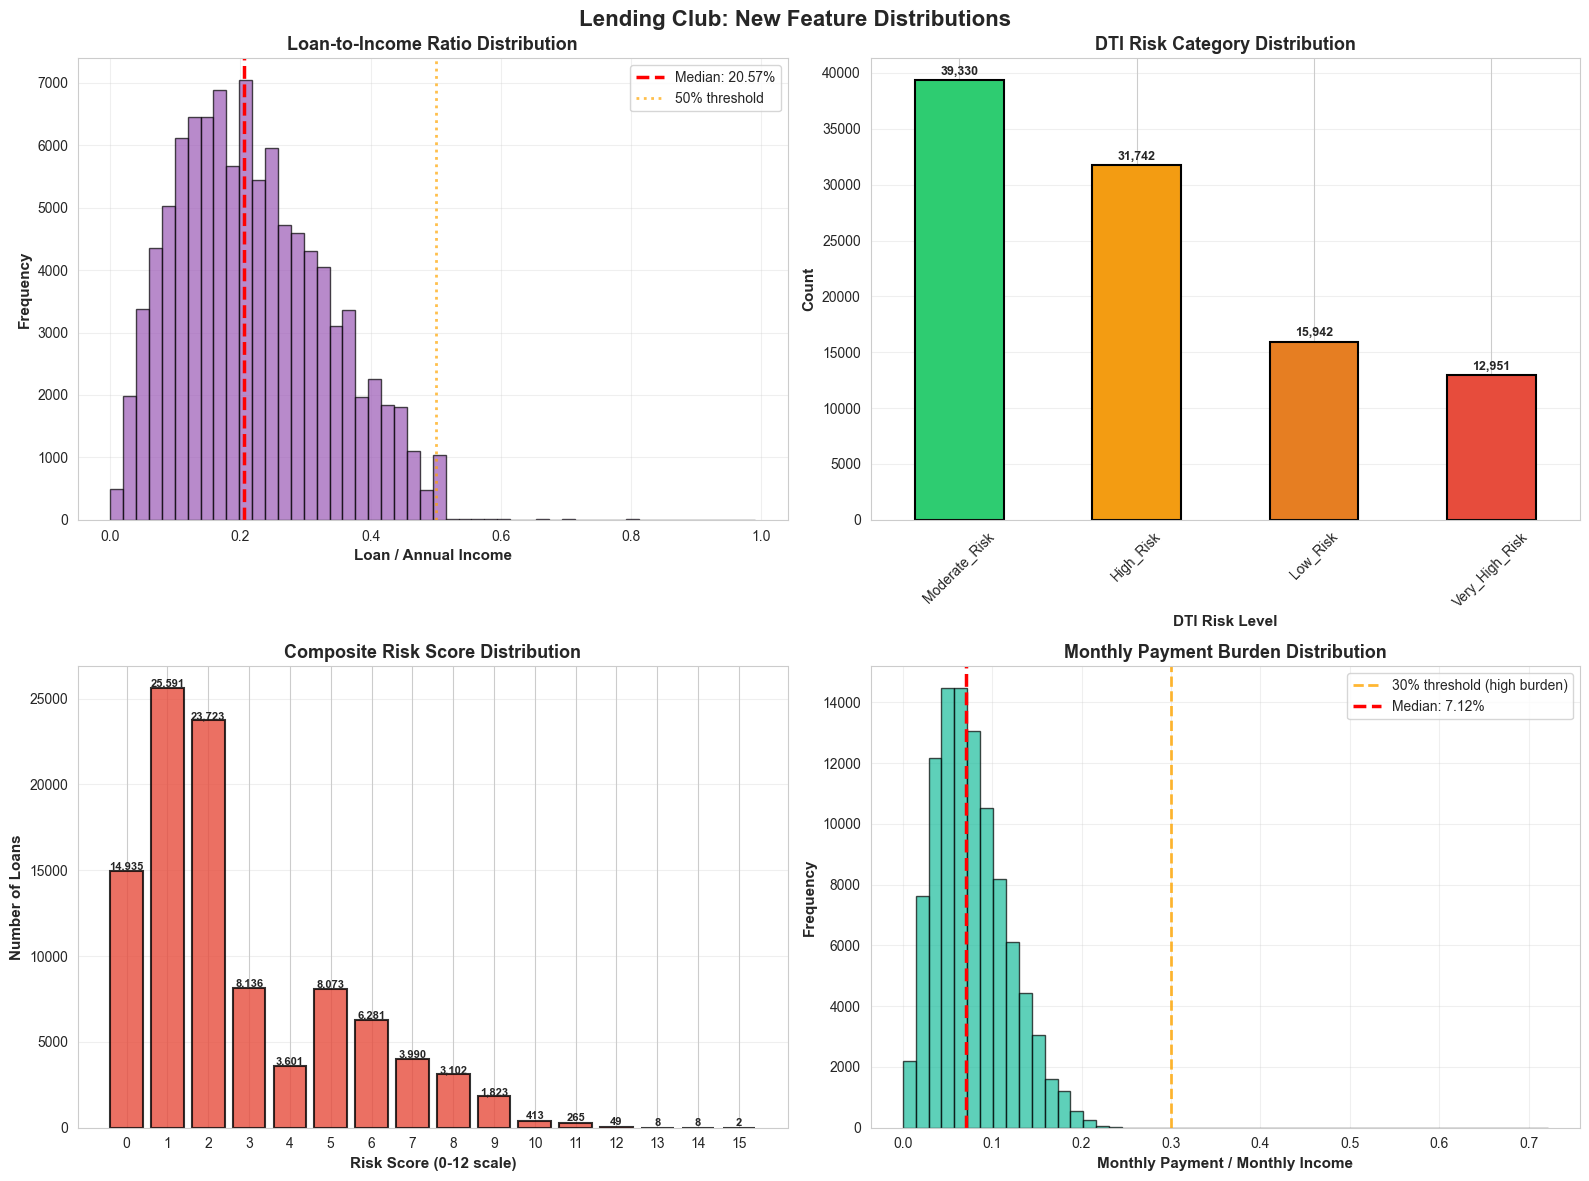

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Lending Club: New Feature Distributions', fontsize=16, fontweight='bold')

# Panel 1: Loan to Income Ratio
lti_filtered = lending_club_fe['loan_to_income_ratio'][lending_club_fe['loan_to_income_ratio'] < 1]
axes[0, 0].hist(lti_filtered, bins=50, color='#9b59b6', edgecolor='black',
                alpha=0.7, linewidth=1)
median_lti = lending_club_fe['loan_to_income_ratio'].median()
axes[0, 0].axvline(median_lti, color='red', linestyle='--', linewidth=2.5,
                   label=f'Median: {median_lti:.2%}')
axes[0, 0].axvline(0.5, color='orange', linestyle=':', linewidth=2,
                   label='50% threshold', alpha=0.7)
axes[0, 0].set_title('Loan-to-Income Ratio Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Loan / Annual Income', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(alpha=0.3)

# Panel 2: DTI Risk Category
dti_risk_counts = lending_club_fe['dti_risk_category'].value_counts()
dti_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
dti_risk_counts.plot(kind='bar', ax=axes[0, 1], color=dti_colors,
                     edgecolor='black', linewidth=1.5)
axes[0, 1].set_title('DTI Risk Category Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('DTI Risk Level', fontsize=11, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(dti_risk_counts.values):
    axes[0, 1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

# Panel 3: Risk Score Distribution
risk_score_counts = lending_club_fe['risk_score'].value_counts().sort_index()
axes[1, 0].bar(range(len(risk_score_counts)), risk_score_counts.values,
               color='#e74c3c', edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1, 0].set_xticks(range(len(risk_score_counts)))
axes[1, 0].set_xticklabels(risk_score_counts.index, fontsize=10)
axes[1, 0].set_title('Composite Risk Score Distribution', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Risk Score (0-12 scale)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Number of Loans', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(risk_score_counts.values):
    axes[1, 0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold', fontsize=8)

# Panel 4: Monthly Payment Burden
burden_filtered = lending_club_fe['monthly_payment_burden'][lending_club_fe['monthly_payment_burden'] < 1]
axes[1, 1].hist(burden_filtered, bins=50, color='#1abc9c', edgecolor='black',
                alpha=0.7, linewidth=1)
axes[1, 1].axvline(0.3, color='orange', linestyle='--', linewidth=2,
                   label='30% threshold (high burden)', alpha=0.8)
median_burden = lending_club_fe['monthly_payment_burden'].median()
axes[1, 1].axvline(median_burden, color='red', linestyle='--', linewidth=2.5,
                   label=f'Median: {median_burden:.2%}')
axes[1, 1].set_title('Monthly Payment Burden Distribution', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Monthly Payment / Monthly Income', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
os.makedirs('results/preprocessing', exist_ok=True)
plt.savefig('results/preprocessing/day2_05_lending_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

Creating visualizations for Credit Card Fraud new features

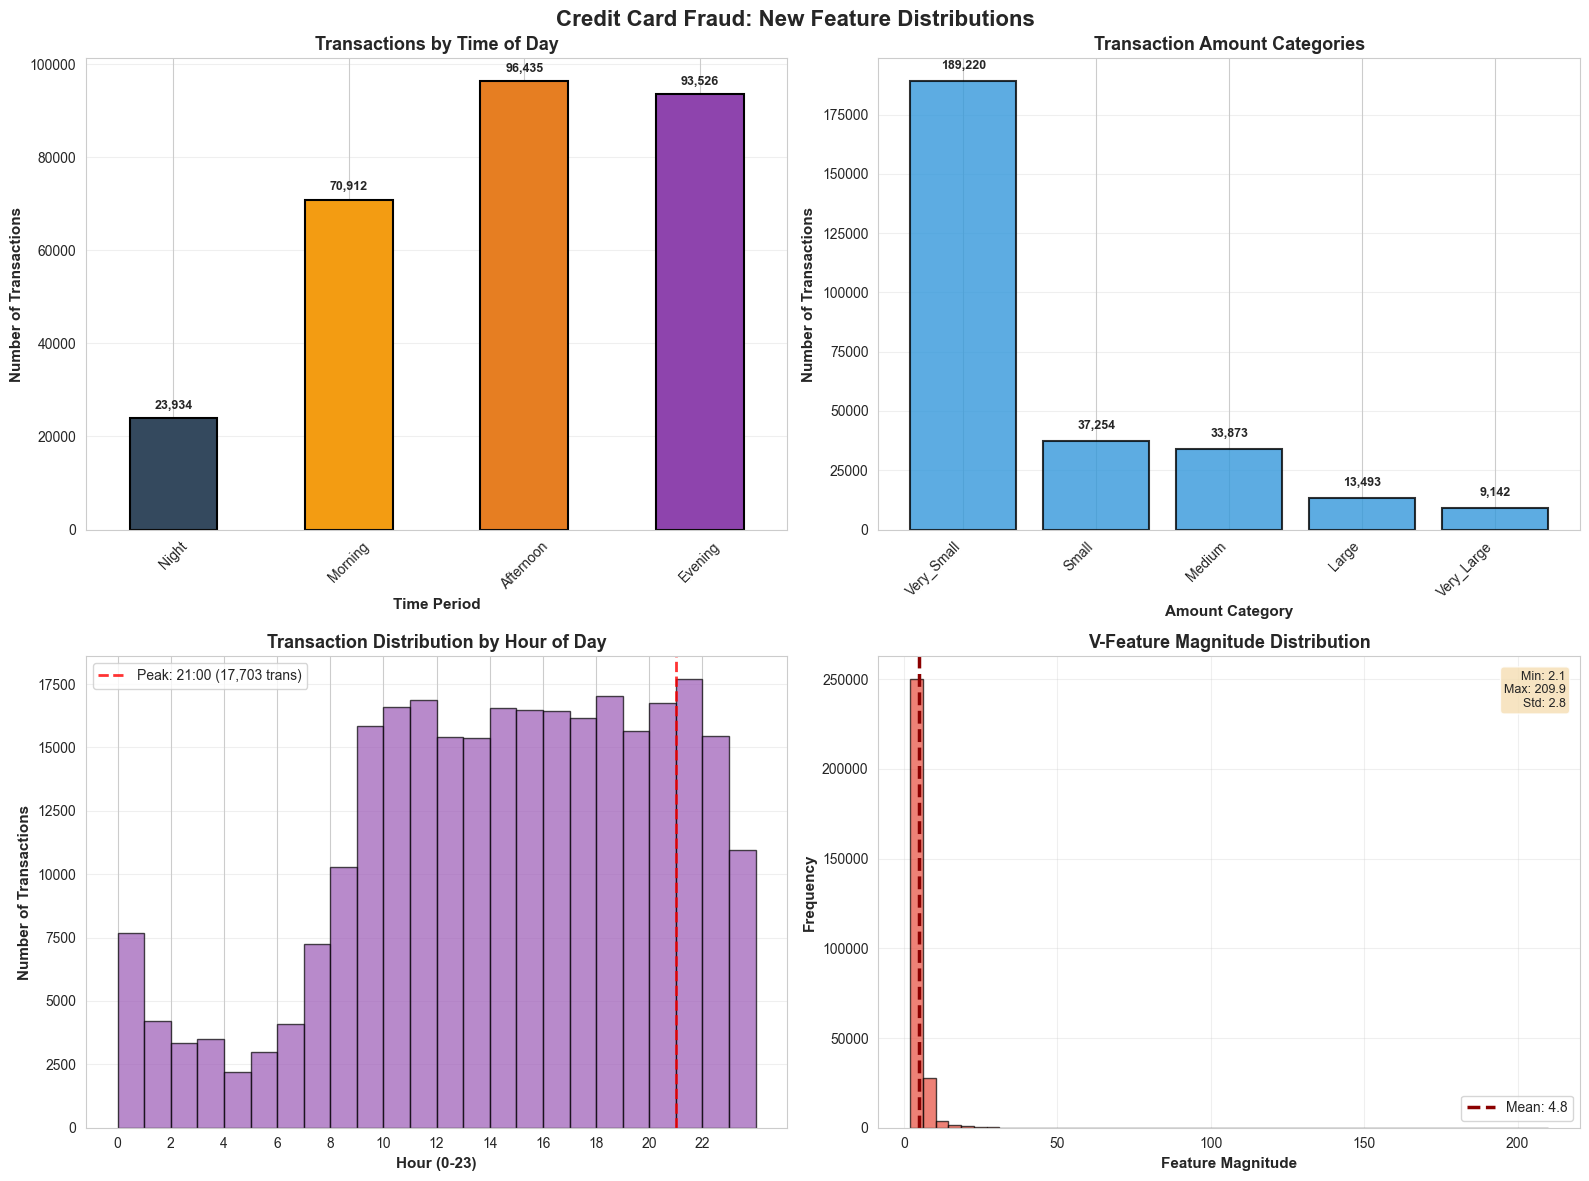

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Credit Card Fraud: New Feature Distributions', fontsize=16, fontweight='bold')

# Panel 1: Time of Day Distribution
time_counts = fraud_data_fe['time_of_day'].value_counts()
time_order = ['Night', 'Morning', 'Afternoon', 'Evening']
time_counts = time_counts.reindex(time_order)
colors_time = ['#34495e', '#f39c12', '#e67e22', '#8e44ad']
time_counts.plot(kind='bar', ax=axes[0, 0], color=colors_time,
                 edgecolor='black', linewidth=1.5)
axes[0, 0].set_title('Transactions by Time of Day', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Number of Transactions', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Time Period', fontsize=11, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(time_counts.values):
    axes[0, 0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

# Panel 2: Amount Category
amount_cat_counts = fraud_data_fe['amount_category'].value_counts()
axes[0, 1].bar(range(len(amount_cat_counts)), amount_cat_counts.values,
               color='#3498db', edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0, 1].set_xticks(range(len(amount_cat_counts)))
axes[0, 1].set_xticklabels(amount_cat_counts.index, fontsize=10, rotation=45, ha='right')
axes[0, 1].set_title('Transaction Amount Categories', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Number of Transactions', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Amount Category', fontsize=11, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(amount_cat_counts.values):
    axes[0, 1].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

# Panel 3: Hourly Distribution
axes[1, 0].hist(fraud_data_fe['hour'], bins=24, color='#9b59b6',
                edgecolor='black', alpha=0.7, linewidth=1, range=(0, 24))
axes[1, 0].set_title('Transaction Distribution by Hour of Day', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Hour (0-23)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Number of Transactions', fontsize=11, fontweight='bold')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(alpha=0.3, axis='y')

# Highlight peak hour
peak_hour = fraud_data_fe['hour'].mode()[0]
peak_count = (fraud_data_fe['hour'] == peak_hour).sum()
axes[1, 0].axvline(peak_hour, color='red', linestyle='--', linewidth=2,
                   label=f'Peak: {peak_hour}:00 ({peak_count:,} trans)', alpha=0.8)
axes[1, 0].legend(fontsize=10)

# Panel 4: V-Feature Magnitude
axes[1, 1].hist(fraud_data_fe['v_feature_magnitude'], bins=50,
                color='#e74c3c', edgecolor='black', alpha=0.7, linewidth=1)
mean_mag = fraud_data_fe['v_feature_magnitude'].mean()
axes[1, 1].axvline(mean_mag, color='darkred', linestyle='--', linewidth=2.5,
                   label=f'Mean: {mean_mag:.1f}')
axes[1, 1].set_title('V-Feature Magnitude Distribution', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Feature Magnitude', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(alpha=0.3)

# Add statistics box
stats_text = f'Min: {fraud_data_fe["v_feature_magnitude"].min():.1f}\nMax: {fraud_data_fe["v_feature_magnitude"].max():.1f}\nStd: {fraud_data_fe["v_feature_magnitude"].std():.1f}'
axes[1, 1].text(0.98, 0.97, stats_text, transform=axes[1, 1].transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
os.makedirs('results/preprocessing', exist_ok=True)
plt.savefig('results/preprocessing/day2_06_fraud_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

Creating feature comparison visualization

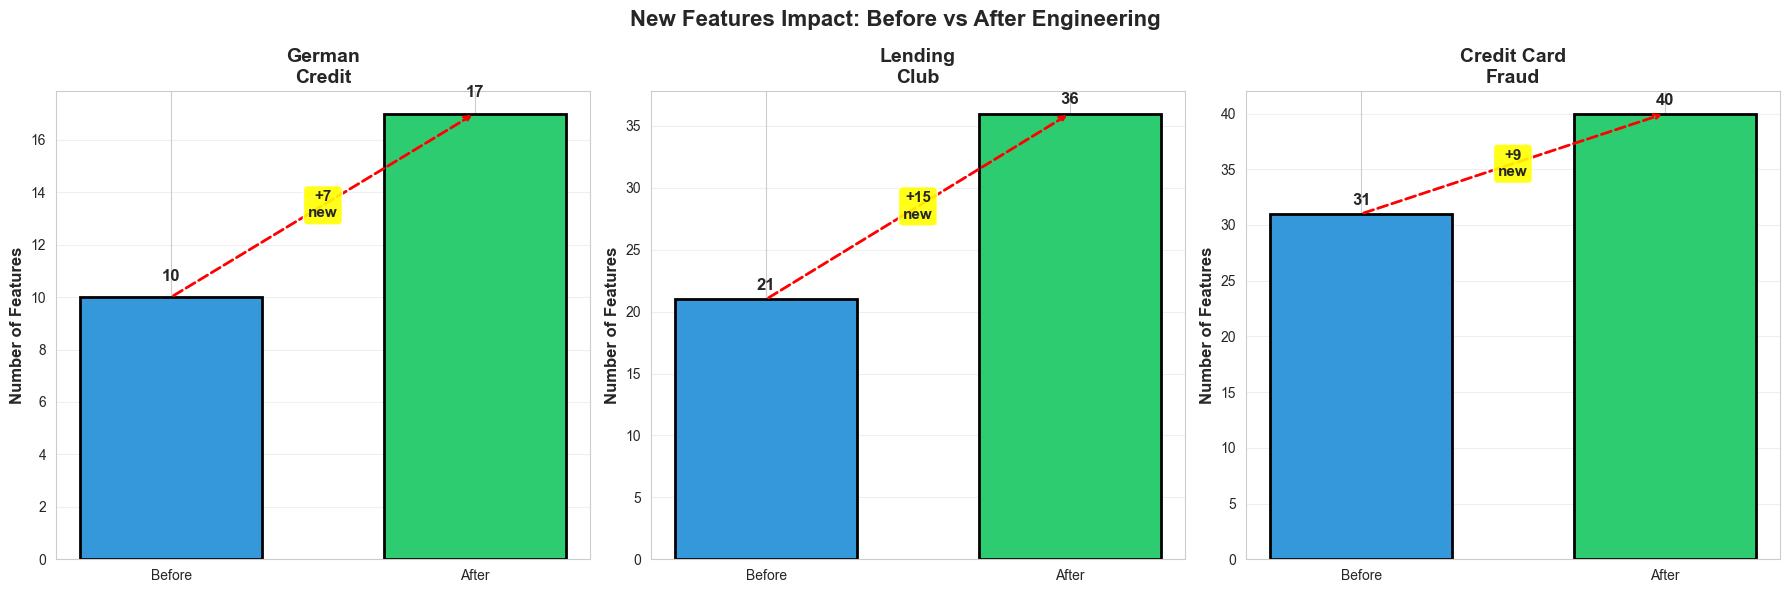

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('New Features Impact: Before vs After Engineering', fontsize=16, fontweight='bold')

datasets = ['German\nCredit', 'Lending\nClub', 'Credit Card\nFraud']
before = [
    len(german_credit_clean.columns),
    len(lending_club_clean.columns),
    len(fraud_data.columns)
]
after = [
    len(german_credit_fe.columns),
    len(lending_club_fe.columns),
    len(fraud_data_fe.columns)
]
new_features = [after[i] - before[i] for i in range(3)]

for idx, (ax, dataset, b, a, n) in enumerate(zip(axes, datasets, before, after, new_features)):
    # Create bars
    bars = ax.bar(['Before', 'After'], [b, a], color=['#3498db', '#2ecc71'],
                  edgecolor='black', linewidth=2, width=0.6)

    ax.set_title(dataset, fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Features', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, val in zip(bars, [b, a]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(val)}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)

    # Add arrow and new features count
    ax.annotate('', xy=(1, a), xytext=(0, b),
                arrowprops=dict(arrowstyle='->', color='red', lw=2, ls='--'))

    mid_y = (b + a) / 2
    ax.text(0.5, mid_y, f'+{n}\nnew', ha='center', va='center',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.9))

plt.tight_layout()
os.makedirs('results/preprocessing', exist_ok=True)
plt.savefig('results/preprocessing/day2_07_feature_engineering_impact.png', dpi=300, bbox_inches='tight')
plt.show()

# Preliminary Feature Importance Analysis

Goal: Identify which features are most predictive of outcomes
* Correlation analysis with target
* Feature importance ranking
* Guide feature selection for modeling

In [47]:
from scipy.stats import chi2_contingency

Lending Club - Correlation Analysis

In [48]:
print(f"\n📊 Target variable: loan_status_binary")
print("")
print(f"   Distribution:")
print(lending_club_fe['loan_status_binary'].value_counts())
print(f"   Default rate: {lending_club_fe['loan_status_binary'].mean()*100:.2f}%\n")

# Select only numerical features for correlation
numerical_features = lending_club_fe.select_dtypes(include=[np.number]).columns.tolist()

# Remove target from features list
if 'loan_status_binary' in numerical_features:
    numerical_features.remove('loan_status_binary')

print(f"Analyzing {len(numerical_features)} numerical features...\n")

# Calculate correlations with target
correlations = lending_club_fe[numerical_features].corrwith(lending_club_fe['loan_status_binary'])

# Remove NaN values
correlations = correlations.dropna()

# Sort by absolute value
correlations_abs = correlations.abs().sort_values(ascending=False)

print("🔝 Top 15 Features by Correlation Strength:\n")
for i, (feature, corr) in enumerate(correlations_abs.head(15).items(), 1):
    actual_corr = correlations[feature]
    direction = "↑ Higher = More Default" if actual_corr > 0 else "↓ Higher = Less Default"
    print(f"   {i:2d}. {feature:30s} {actual_corr:+.4f}  {direction}")

# Separate positive and negative correlations
positive_corr = correlations[correlations > 0].sort_values(ascending=False).head(10)
negative_corr = correlations[correlations < 0].sort_values().head(10)


📊 Target variable: loan_status_binary

   Distribution:
loan_status_binary
0    81889
1    18111
Name: count, dtype: int64
   Default rate: 18.11%

Analyzing 22 numerical features...

🔝 Top 15 Features by Correlation Strength:

    1. int_rate                       +0.2613  ↑ Higher = More Default
    2. grade_risk_points              +0.2556  ↑ Higher = More Default
    3. risk_score                     +0.2468  ↑ Higher = More Default
    4. total_interest_paid            +0.1608  ↑ Higher = More Default
    5. loan_term_months               +0.1188  ↑ Higher = More Default
    6. loan_to_income_ratio           +0.1013  ↑ Higher = More Default
    7. monthly_payment_burden         +0.0942  ↑ Higher = More Default
    8. dti                            +0.0876  ↑ Higher = More Default
    9. total_payment_amount           +0.0811  ↑ Higher = More Default
   10. credit_history_years           -0.0476  ↓ Higher = Less Default
   11. monthly_income                 -0.0380  ↓ Higher = Les

Visualization: Top Correlations

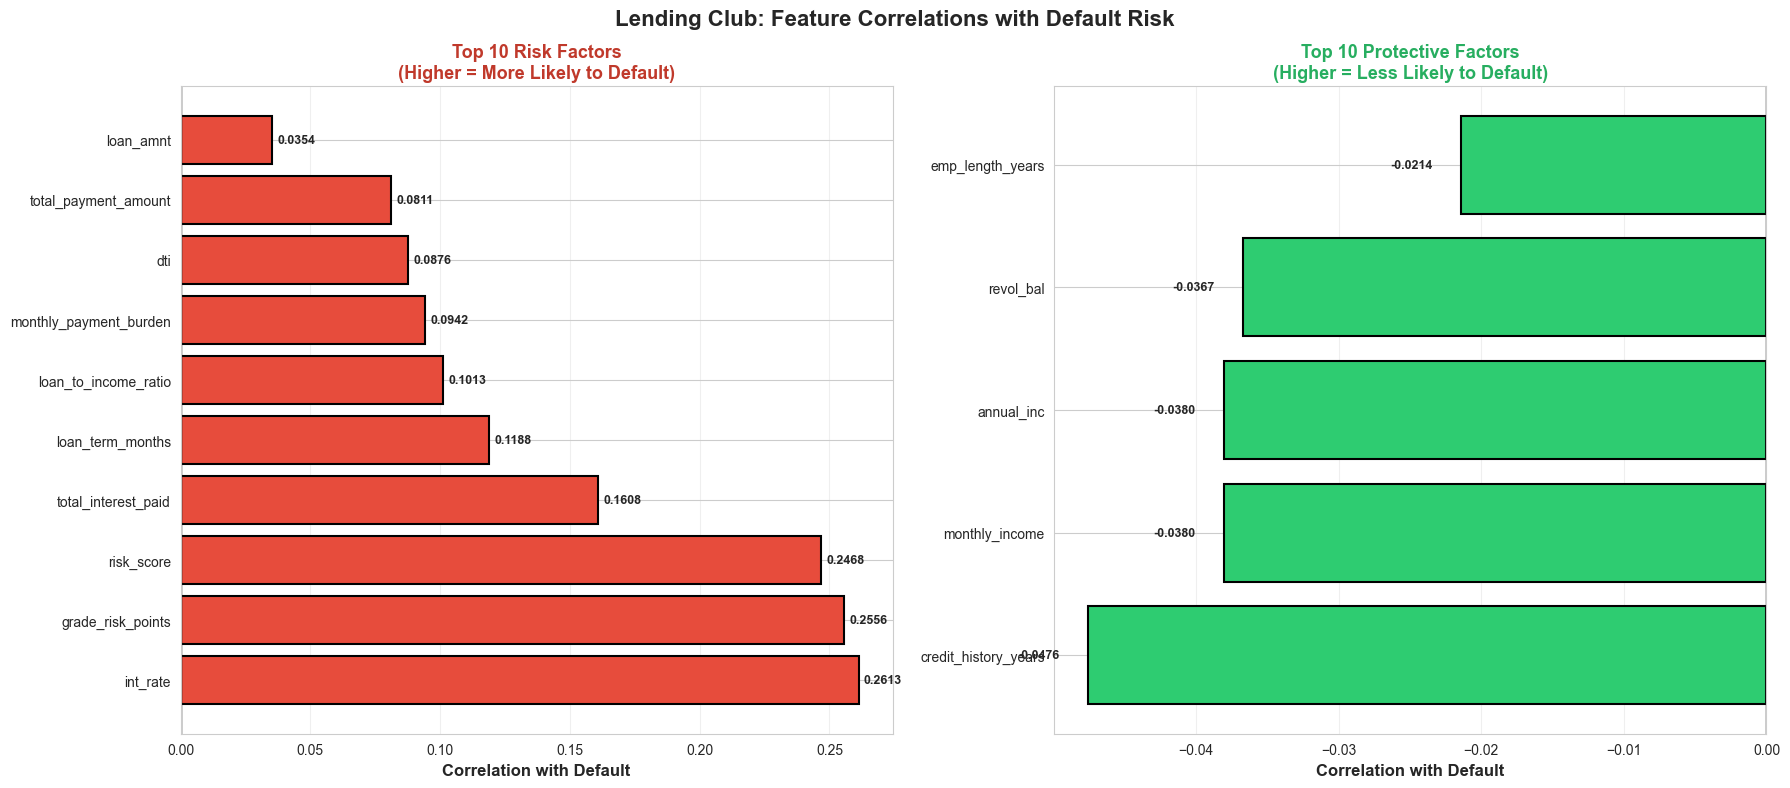

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Lending Club: Feature Correlations with Default Risk',
              fontsize=16, fontweight='bold')

# Left: Positive correlations (risk factors)
axes[0].barh(range(len(positive_corr)), positive_corr.values,
              color='#e74c3c', edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(positive_corr)))
axes[0].set_yticklabels(positive_corr.index, fontsize=10)
axes[0].set_xlabel('Correlation with Default', fontsize=12, fontweight='bold')
axes[0].set_title('Top 10 Risk Factors\n(Higher = More Likely to Default)',
                  fontsize=13, fontweight='bold', color='#c0392b')
axes[0].grid(alpha=0.3, axis='x')
axes[0].axvline(0, color='black', linewidth=1)

# Add value labels
for i, v in enumerate(positive_corr.values):
    axes[0].text(v + 0.002, i, f'{v:.4f}',
                va='center', fontsize=9, fontweight='bold')

# Right: Negative correlations (protective factors)
axes[1].barh(range(len(negative_corr)), negative_corr.values,
              color='#2ecc71', edgecolor='black', linewidth=1.5)
axes[1].set_yticks(range(len(negative_corr)))
axes[1].set_yticklabels(negative_corr.index, fontsize=10)
axes[1].set_xlabel('Correlation with Default', fontsize=12, fontweight='bold')
axes[1].set_title('Top 10 Protective Factors\n(Higher = Less Likely to Default)',
                  fontsize=13, fontweight='bold', color='#27ae60')
axes[1].grid(alpha=0.3, axis='x')
axes[1].axvline(0, color='black', linewidth=1)

# Add value labels
for i, v in enumerate(negative_corr.values):
    axes[1].text(v - 0.002, i, f'{v:.4f}',
                va='center', ha='right', fontsize=9, fontweight='bold')

plt.tight_layout()
os.makedirs('results/preprocessing', exist_ok=True)
plt.savefig('results/preprocessing/day2_08_lending_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

In [50]:
print("\n" + "="*70)
print("💡 KEY INSIGHTS - LENDING CLUB")
print("="*70)

print("\n🚨 TOP RISK FACTORS (Higher value = More likely to default):")
for i, (feature, corr) in enumerate(positive_corr.head(5).items(), 1):
    print(f"   {i}. {feature}: {corr:+.4f}")

print("\n✅ TOP PROTECTIVE FACTORS (Higher value = Less likely to default):")
for i, (feature, corr) in enumerate(negative_corr.head(5).items(), 1):
    print(f"   {i}. {feature}: {corr:.4f}")


💡 KEY INSIGHTS - LENDING CLUB

🚨 TOP RISK FACTORS (Higher value = More likely to default):
   1. int_rate: +0.2613
   2. grade_risk_points: +0.2556
   3. risk_score: +0.2468
   4. total_interest_paid: +0.1608
   5. loan_term_months: +0.1188

✅ TOP PROTECTIVE FACTORS (Higher value = Less likely to default):
   1. credit_history_years: -0.0476
   2. monthly_income: -0.0380
   3. annual_inc: -0.0380
   4. revol_bal: -0.0367
   5. emp_length_years: -0.0214


Credit Card Fraud - Correlation Analysis

In [51]:
print(f"\n📊 Target variable: Class")
print("")
print(f"   Distribution:")
print(fraud_data_fe['Class'].value_counts())
print(f"   Fraud rate: {fraud_data_fe['Class'].mean()*100:.4f}%\n")

# Select numerical features
fraud_numerical = fraud_data_fe.select_dtypes(include=[np.number]).columns.tolist()

# Remove target
if 'Class' in fraud_numerical:
    fraud_numerical.remove('Class')

print(f"Analyzing {len(fraud_numerical)} numerical features...\n")

# Calculate correlations
fraud_correlations = fraud_data_fe[fraud_numerical].corrwith(fraud_data_fe['Class'])
fraud_correlations = fraud_correlations.dropna()

# Sort by absolute value
fraud_corr_abs = fraud_correlations.abs().sort_values(ascending=False).head(20)

print("🔝 Top 20 Features by Correlation Strength:\n")
for i, (feature, _) in enumerate(fraud_corr_abs.items(), 1):
    actual_corr = fraud_correlations[feature]
    direction = "↑ Higher = More Fraud" if actual_corr > 0 else "↓ Higher = Less Fraud"
    print(f"   {i:2d}. {feature:25s} {actual_corr:+.4f}  {direction}")


📊 Target variable: Class

   Distribution:
Class
0    284315
1       492
Name: count, dtype: int64
   Fraud rate: 0.1727%

Analyzing 37 numerical features...

🔝 Top 20 Features by Correlation Strength:

    1. V17                       -0.3265  ↓ Higher = Less Fraud
    2. V14                       -0.3025  ↓ Higher = Less Fraud
    3. v_feature_magnitude       +0.2679  ↑ Higher = More Fraud
    4. V12                       -0.2606  ↓ Higher = Less Fraud
    5. V10                       -0.2169  ↓ Higher = Less Fraud
    6. V16                       -0.1965  ↓ Higher = Less Fraud
    7. V3                        -0.1930  ↓ Higher = Less Fraud
    8. V7                        -0.1873  ↓ Higher = Less Fraud
    9. V11                       +0.1549  ↑ Higher = More Fraud
   10. V4                        +0.1334  ↑ Higher = More Fraud
   11. V18                       -0.1115  ↓ Higher = Less Fraud
   12. V1                        -0.1013  ↓ Higher = Less Fraud
   13. V9                   

Visualization: Fraud Correlations

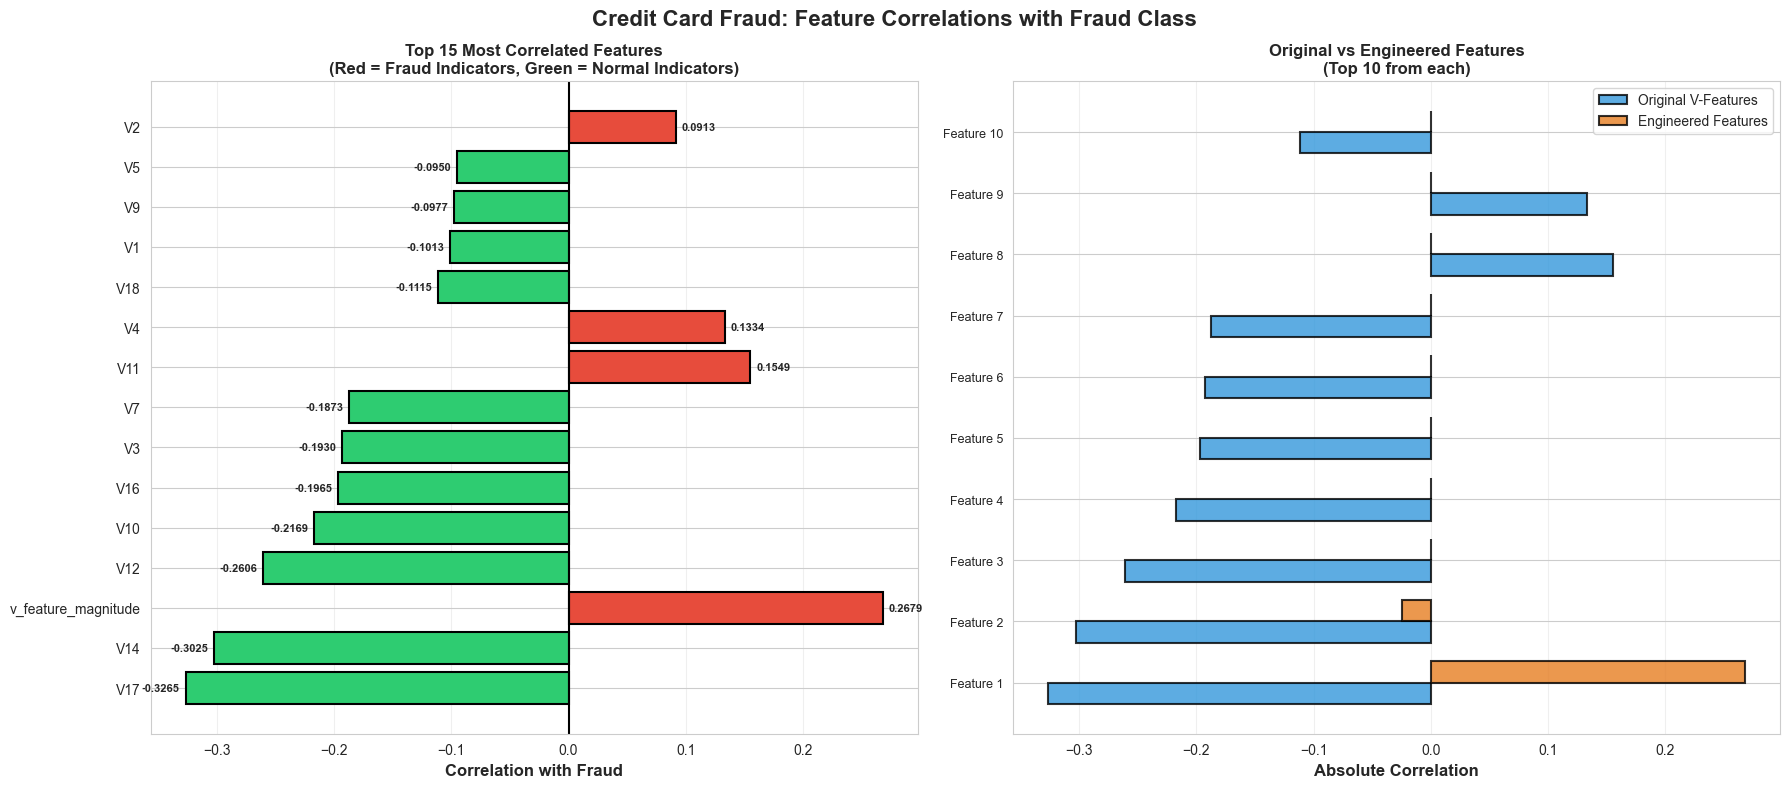

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Credit Card Fraud: Feature Correlations with Fraud Class',
             fontsize=16, fontweight='bold')

# Left: Top 15 by absolute correlation
top_15 = fraud_corr_abs.head(15)
colors_fraud = ['#e74c3c' if fraud_correlations[f] > 0 else '#2ecc71' for f in top_15.index]

axes[0].barh(range(len(top_15)), [fraud_correlations[f] for f in top_15.index],
             color=colors_fraud, edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15.index, fontsize=10)
axes[0].set_xlabel('Correlation with Fraud', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Most Correlated Features\n(Red = Fraud Indicators, Green = Normal Indicators)',
                 fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')
axes[0].axvline(0, color='black', linewidth=1.5)

# Add value labels
for i, feature in enumerate(top_15.index):
    v = fraud_correlations[feature]
    x_pos = v + (0.005 if v > 0 else -0.005)
    ha = 'left' if v > 0 else 'right'
    axes[0].text(x_pos, i, f'{v:.4f}', va='center', ha=ha,
                fontsize=8, fontweight='bold')

# Right: Compare V-features vs new features
v_features = [f for f in fraud_corr_abs.index if f.startswith('V')][:10]
new_features = [f for f in fraud_corr_abs.index if not f.startswith('V') and f != 'Time'][:10]

comparison_data = {
    'V-Features': [fraud_correlations[f] for f in v_features],
    'New Features': [fraud_correlations[f] for f in new_features]
}

x_pos = np.arange(max(len(v_features), len(new_features)))
width = 0.35

# Pad shorter list with NaN
if len(v_features) < len(new_features):
    v_features += [''] * (len(new_features) - len(v_features))
    comparison_data['V-Features'] += [0] * (len(new_features) - len(comparison_data['V-Features']))
elif len(new_features) < len(v_features):
    new_features += [''] * (len(v_features) - len(new_features))
    comparison_data['New Features'] += [0] * (len(v_features) - len(comparison_data['New Features']))

bars1 = axes[1].barh(x_pos - width/2, comparison_data['V-Features'], width,
                     label='Original V-Features', color='#3498db',
                     edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = axes[1].barh(x_pos + width/2, comparison_data['New Features'], width,
                     label='Engineered Features', color='#e67e22',
                     edgecolor='black', linewidth=1.5, alpha=0.8)

axes[1].set_yticks(x_pos)
axes[1].set_yticklabels([f'Feature {i+1}' for i in range(len(x_pos))], fontsize=9)
axes[1].set_xlabel('Absolute Correlation', fontsize=12, fontweight='bold')
axes[1].set_title('Original vs Engineered Features\n(Top 10 from each)',
                 fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
os.makedirs('results/preprocessing', exist_ok=True)
plt.savefig('results/preprocessing/day2_09_fraud_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

In [53]:
print("\n" + "="*70)
print("💡 KEY INSIGHTS - CREDIT CARD FRAUD")
print("="*70)

top_fraud_indicators = fraud_correlations[fraud_correlations > 0].sort_values(ascending=False).head(5)
top_normal_indicators = fraud_correlations[fraud_correlations < 0].sort_values().head(5)

print("\n🚨 TOP FRAUD INDICATORS (Higher value = More likely fraud):")
for i, (feature, corr) in enumerate(top_fraud_indicators.items(), 1):
    print(f"   {i}. {feature}: {corr:+.4f}")

print("\n✅ TOP NORMAL INDICATORS (Higher value = More likely normal):")
for i, (feature, corr) in enumerate(top_normal_indicators.items(), 1):
    print(f"   {i}. {feature}: {corr:.4f}")


💡 KEY INSIGHTS - CREDIT CARD FRAUD

🚨 TOP FRAUD INDICATORS (Higher value = More likely fraud):
   1. v_feature_magnitude: +0.2679
   2. V11: +0.1549
   3. V4: +0.1334
   4. V2: +0.0913
   5. V21: +0.0404

✅ TOP NORMAL INDICATORS (Higher value = More likely normal):
   1. V17: -0.3265
   2. V14: -0.3025
   3. V12: -0.2606
   4. V10: -0.2169
   5. V16: -0.1965


Feature Correlation Heatmap


📊 Creating Lending Club feature correlation matrix...


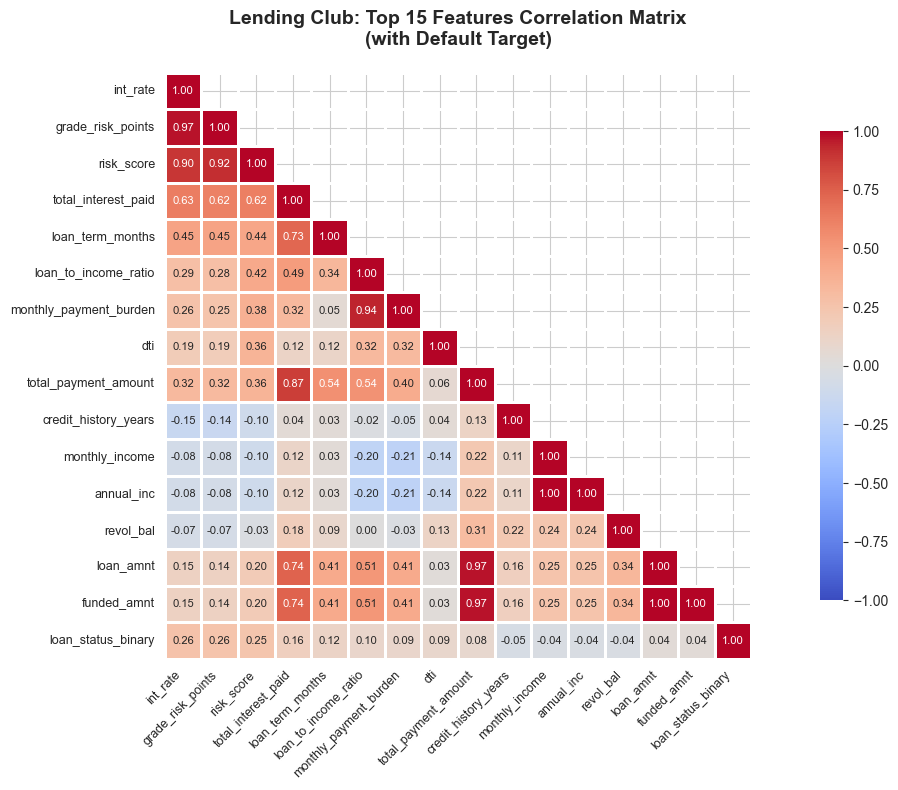


📊 Creating Fraud dataset new features correlation matrix...


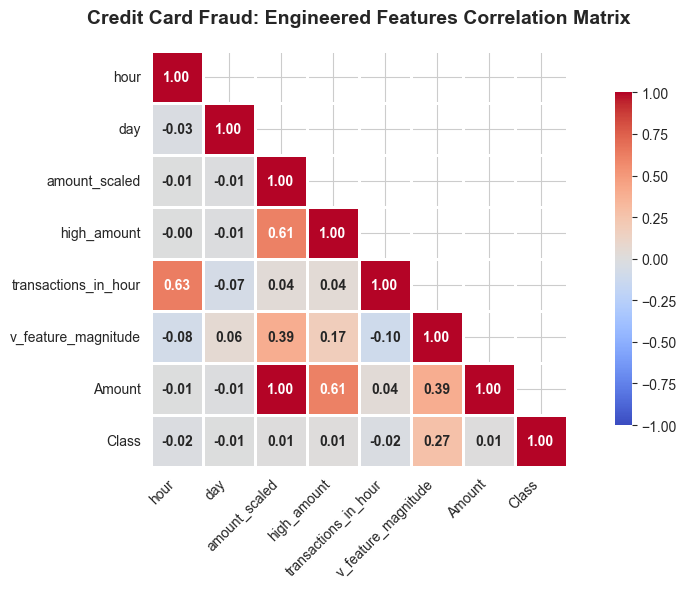

In [54]:
# Lending Club - Top features correlation matrix
if 'loan_status_binary' in lending_club_fe.columns:
    print("\n📊 Creating Lending Club feature correlation matrix...")

    # Select top 15 features by correlation with target
    top_features_lending = correlations_abs.head(15).index.tolist()
    top_features_lending.append('loan_status_binary')

    # Create correlation matrix
    corr_matrix_lending = lending_club_fe[top_features_lending].corr()

    # Visualize
    plt.figure(figsize=(14, 8))
    mask = np.triu(np.ones_like(corr_matrix_lending, dtype=bool), k=1)

    sns.heatmap(corr_matrix_lending, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, square=True, linewidths=1,
                cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1,
                annot_kws={'fontsize': 8})

    plt.title('Lending Club: Top 15 Features Correlation Matrix\n(with Default Target)',
              fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    os.makedirs('results/preprocessing', exist_ok=True)
    plt.savefig('results/preprocessing/day2_10_lending_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


# Fraud - New features correlation matrix
print("\n📊 Creating Fraud dataset new features correlation matrix...")

# Select our engineered features
new_fraud_features = ['hour', 'day', 'amount_scaled', 'high_amount',
                      'transactions_in_hour', 'v_feature_magnitude', 'Amount', 'Class']

# Create correlation matrix
corr_matrix_fraud = fraud_data_fe[new_fraud_features].corr()

# Visualize
plt.figure(figsize=(10, 6))
mask = np.triu(np.ones_like(corr_matrix_fraud, dtype=bool), k=1)

sns.heatmap(corr_matrix_fraud, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=2,
            cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1,
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})

plt.title('Credit Card Fraud: Engineered Features Correlation Matrix',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
os.makedirs('results/preprocessing', exist_ok=True)
plt.savefig('results/preprocessing/day2_11_fraud_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Categorical Feature Analysis

In [55]:
if 'loan_status_binary' in lending_club_fe.columns:
    print("\n📊 Lending Club: Categorical features vs Default\n")

    categorical_features = lending_club_fe.select_dtypes(include=['object', 'category']).columns.tolist()

    # Remove target if present
    if 'loan_status' in categorical_features:
        categorical_features.remove('loan_status')

    chi_square_results = []

    for feature in categorical_features[:10]:  # Analyze top 10
        if feature in lending_club_fe.columns and lending_club_fe[feature].notna().any():
            # Create contingency table
            contingency_table = pd.crosstab(lending_club_fe[feature],
                                           lending_club_fe['loan_status_binary'])

            # Chi-square test
            try:
                chi2, p_value, dof, expected = chi2_contingency(contingency_table)
                chi_square_results.append({
                    'Feature': feature,
                    'Chi-Square': chi2,
                    'P-Value': p_value,
                    'Significant': 'Yes ✓' if p_value < 0.05 else 'No'
                })
            except:
                pass

    if chi_square_results:
        chi_df = pd.DataFrame(chi_square_results).sort_values('Chi-Square', ascending=False)

        print("Chi-Square Test Results (Association with Default):")
        print(chi_df.to_string(index=False))

        print("\n💡 Interpretation:")
        print("   • P-Value < 0.05 = Significant association with default")
        print("   • Higher Chi-Square = Stronger association")


📊 Lending Club: Categorical features vs Default

Chi-Square Test Results (Association with Default):
               Feature  Chi-Square       P-Value Significant
             sub_grade 6894.138778  0.000000e+00       Yes ✓
                 grade 6544.459539  0.000000e+00       Yes ✓
interest_rate_category 6202.786678  0.000000e+00       Yes ✓
                  term 1410.473179 1.113246e-308       Yes ✓
      earliest_cr_line  964.837460  1.459341e-17       Yes ✓
   verification_status  940.630341 5.555418e-205       Yes ✓
     dti_risk_category  937.417261 6.773252e-203       Yes ✓
        home_ownership  468.667818 2.940172e-101       Yes ✓
               purpose  383.108774  2.348082e-75       Yes ✓
            emp_length  194.230118  1.168909e-35       Yes ✓

💡 Interpretation:
   • P-Value < 0.05 = Significant association with default
   • Higher Chi-Square = Stronger association


FEATURE IMPORTANCE ANALYSIS

📊 Summary:
* Identified top risk factors and protective factors
* Created correlation heatmaps
* Analyzed categorical feature associations

🎯 Key Takeaways:
* Identified most predictive features
* Understood feature relationships
* Ready for feature selection in modeling
* Know which features to prioritize


Saving Engineered Features

In [56]:
german_credit_fe.to_csv('data/processed/german_credit_step2.csv', index=False)
lending_club_fe.to_csv('data/processed/lending_club_step2.csv', index=False)
fraud_data_fe.to_csv('data/processed/fraud_step2.csv', index=False)

# Summary - Feature Engineering

Quick Summary Table

In [57]:
summary_data = {
    'Dataset': ['German Credit', 'Lending Club', 'Credit Card Fraud'],
    'Original Features': [
        len(german_credit_clean.columns),
        len(lending_club_clean.columns),
        len(fraud_data.columns)
    ],
    'New Features': [
        len(german_credit_fe.columns) - len(german_credit_clean.columns),
        len(lending_club_fe.columns) - len(lending_club_clean.columns),
        len(fraud_data_fe.columns) - len(fraud_data.columns)
    ],
    'Total Features': [
        len(german_credit_fe.columns),
        len(lending_club_fe.columns),
        len(fraud_data_fe.columns)
    ]
}

summary_df = pd.DataFrame(summary_data)

print("Feature Engineering Results:")
print(summary_df.to_string(index=False))

Feature Engineering Results:
          Dataset  Original Features  New Features  Total Features
    German Credit                 10             7              17
     Lending Club                 21            15              36
Credit Card Fraud                 31             9              40


# Encoding Categorical Variables

In [58]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

print("\n🎯 Goal: Convert categorical variables to numerical format")
print("   Ready for machine learning algorithms\n")


🎯 Goal: Convert categorical variables to numerical format
   Ready for machine learning algorithms



German Credit - Encoding

In [59]:
# Create copy
german_encoded = german_credit_fe.copy()

# Identify categorical columns
categorical_cols = german_encoded.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n📋 Found {len(categorical_cols)} categorical columns:")
for col in categorical_cols:
    print(f"   • {col}: {german_encoded[col].nunique()} unique values")

# Strategy 1: Label encode binary columns
binary_cols = [col for col in categorical_cols if german_encoded[col].nunique() == 2]

if binary_cols:
    print(f"\n1️⃣ Label Encoding ({len(binary_cols)} binary columns):")
    le = LabelEncoder()
    for col in binary_cols:
        german_encoded[f'{col}_encoded'] = le.fit_transform(german_encoded[col].astype(str))
        print(f"   ✓ {col} → {col}_encoded")
        print(f"      Values: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Strategy 2: One-hot encode multi-category (PROPER WAY)
multi_cols = [col for col in categorical_cols if col not in binary_cols]

if multi_cols:
    print(f"\n2️⃣ One-Hot Encoding ({len(multi_cols)} columns):")
    for col in multi_cols:
        # Get dummies and convert to INTEGER (not boolean)
        dummies = pd.get_dummies(german_encoded[col], prefix=col, drop_first=True, dtype=int)
        german_encoded = pd.concat([german_encoded, dummies], axis=1)
        print(f"   ✓ {col} → {len(dummies.columns)} columns")
        print(f"      Created: {', '.join(dummies.columns.tolist()[:3])}...")

# Drop original categorical columns
german_encoded = german_encoded.drop(columns=categorical_cols)

print(f"\n✅ Encoding complete!")
print(f"   Before: {len(german_credit_fe.columns)} columns")
print(f"   After: {len(german_encoded.columns)} columns")

# Show sample
print(f"\n📊 Sample of encoded data:")
german_encoded.head(3)


📋 Found 9 categorical columns:
   • Sex: 2 unique values
   • Housing: 3 unique values
   • Saving accounts: 4 unique values
   • Checking account: 3 unique values
   • Purpose: 8 unique values
   • age_group: 4 unique values
   • credit_category: 4 unique values
   • duration_category: 4 unique values
   • purpose_risk_level: 3 unique values

1️⃣ Label Encoding (1 binary columns):
   ✓ Sex → Sex_encoded
      Values: {'female': 0, 'male': 1}

2️⃣ One-Hot Encoding (8 columns):
   ✓ Housing → 2 columns
      Created: Housing_own, Housing_rent...
   ✓ Saving accounts → 3 columns
      Created: Saving accounts_moderate, Saving accounts_quite rich, Saving accounts_rich...
   ✓ Checking account → 2 columns
      Created: Checking account_moderate, Checking account_rich...
   ✓ Purpose → 7 columns
      Created: Purpose_car, Purpose_domestic appliances, Purpose_education...
   ✓ age_group → 3 columns
      Created: age_group_Middle_Age, age_group_Mature, age_group_Senior...
   ✓ credit_cate

,Unnamed: 0,Age,Job,Credit amount,Duration,monthly_payment,high_value_loan,age_to_duration_ratio,Sex_encoded,Housing_own,...,age_group_Mature,age_group_Senior,credit_category_Medium,credit_category_Large,credit_category_Very_Large,duration_category_Medium_Term,duration_category_Long_Term,duration_category_Very_Long,purpose_risk_level_Low,purpose_risk_level_Medium
0,0,67,2,1169,6,194.833333,0,11.166667,1,1,...,0,1,0,0,0,0,0,0,1,0
1,1,22,2,5951,48,123.979167,1,0.458333,0,1,...,0,0,0,1,0,0,0,1,1,0
2,2,49,1,2096,12,174.666667,0,4.083333,1,1,...,1,0,1,0,0,0,0,0,0,1


Lending Club - Encoding

In [60]:
lending_encoded = lending_club_fe.copy()

categorical_cols = lending_encoded.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n📋 Found {len(categorical_cols)} categorical columns")

# Binary columns
binary_cols = [col for col in categorical_cols if lending_encoded[col].nunique() <= 2]

if binary_cols:
    print(f"\n1️⃣ Label Encoding ({len(binary_cols)} binary columns):")
    le = LabelEncoder()
    for col in binary_cols:
        try:
            lending_encoded[f'{col}_encoded'] = le.fit_transform(lending_encoded[col].astype(str))
            print(f"   ✓ {col}")
        except:
            print(f"   ⚠️ Skipped {col}")

# Low-cardinality one-hot (≤10 categories)
onehot_cols = [col for col in categorical_cols
               if col not in binary_cols and lending_encoded[col].nunique() <= 10]

if onehot_cols:
    print(f"\n2️⃣ One-Hot Encoding ({len(onehot_cols)} columns):")
    for col in onehot_cols:
        try:
            # CRITICAL: dtype=int to get 0/1 instead of True/False
            dummies = pd.get_dummies(lending_encoded[col], prefix=col, drop_first=True, dtype=int)
            lending_encoded = pd.concat([lending_encoded, dummies], axis=1)
            print(f"   ✓ {col} → {len(dummies.columns)} columns")
        except:
            print(f"   ⚠️ Skipped {col}")

# Drop high-cardinality and original categorical
drop_cols = [col for col in categorical_cols
             if col not in binary_cols and col not in onehot_cols]

if drop_cols:
    print(f"\n3️⃣ Dropping high-cardinality ({len(drop_cols)} columns)")

all_categorical = list(set(categorical_cols))
lending_encoded = lending_encoded.drop(columns=[col for col in all_categorical
                                                if col in lending_encoded.columns])

print(f"\n✅ Encoding complete!")
print(f"   Before: {len(lending_club_fe.columns)} columns")
print(f"   After: {len(lending_encoded.columns)} columns")
lending_encoded.head(3)


📋 Found 13 categorical columns

1️⃣ Label Encoding (1 binary columns):
   ✓ term

2️⃣ One-Hot Encoding (8 columns):
   ✓ grade → 6 columns
   ✓ home_ownership → 3 columns
   ✓ verification_status → 2 columns
   ✓ loan_status → 6 columns
   ✓ dti_risk_category → 3 columns
   ✓ interest_rate_category → 3 columns
   ✓ emp_stability → 3 columns
   ✓ revol_util_category → 3 columns

3️⃣ Dropping high-cardinality (4 columns)

✅ Encoding complete!
   Before: 36 columns
   After: 53 columns


,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,...,dti_risk_category_Very_High_Risk,interest_rate_category_Medium_Rate,interest_rate_category_High_Rate,interest_rate_category_Very_High_Rate,emp_stability_Stable,emp_stability_Experienced,emp_stability_Very_Experienced,revol_util_category_Medium_Util,revol_util_category_High_Util,revol_util_category_Maxed_Out
0,3600.0,3600.0,13.99,123.03,55000.0,5.91,0.0,7.0,0.0,2765.0,...,0,0,1,0,0,1,0,0,0,0
1,24700.0,24700.0,11.99,820.28,65000.0,16.06,1.0,22.0,0.0,21470.0,...,0,1,0,0,0,1,0,0,0,0
2,20000.0,20000.0,10.78,432.66,63000.0,10.78,0.0,6.0,0.0,7869.0,...,0,1,0,0,0,1,0,0,1,0


Fraud Data - Encoding

In [61]:
# Create copy
fraud_encoded = fraud_data_fe.copy()

categorical_cols = fraud_encoded.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_cols) > 0:
    print(f"\n📋 Found {len(categorical_cols)} categorical columns")

    for col in categorical_cols:
        # CRITICAL: dtype=int
        dummies = pd.get_dummies(fraud_encoded[col], prefix=col, drop_first=True, dtype=int)
        fraud_encoded = pd.concat([fraud_encoded, dummies], axis=1)
        print(f"   ✓ {col} → {len(dummies.columns)} columns")

    fraud_encoded = fraud_encoded.drop(columns=categorical_cols)
    print(f"\n✅ Encoding complete!")
else:
    print("\n✅ No categorical columns - already numerical!")

fraud_encoded.head(3)


📋 Found 2 categorical columns
   ✓ time_of_day → 3 columns
   ✓ amount_category → 4 columns

✅ Encoding complete!


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,hour_bucket,transactions_in_hour,v_feature_magnitude,time_of_day_Evening,time_of_day_Morning,time_of_day_Night,amount_category_Small,amount_category_Medium,amount_category_Large,amount_category_Very_Large
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0,3963,3.911559,0,0,1,0,1,0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0,3963,2.674524,0,0,1,0,0,0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0,3963,6.080512,0,0,1,0,0,1,0


Verification - Show Actual Values

In [62]:
print("\n🔍 German Credit - Sample values:")
print(f"\nData types:")
print(german_encoded.dtypes.value_counts())

print("\n🔍 Lending Club - Sample values:")
print(f"\nData types:")
print(lending_encoded.dtypes.value_counts())

print("\n🔍 Fraud Data - Sample values:")
print(f"\nData types:")
print(fraud_encoded.dtypes.value_counts())

# Check for any object/bool columns
print("\n" + "="*70)
print("FINAL CHECK: ANY NON-NUMERIC COLUMNS?")
print("="*70)

german_non_numeric = german_encoded.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
lending_non_numeric = lending_encoded.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
fraud_non_numeric = fraud_encoded.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

print(f"\nGerman Credit non-numeric: {len(german_non_numeric)} {'❌' if len(german_non_numeric) > 0 else '✅'}")
if german_non_numeric:
    print(f"   Columns: {german_non_numeric}")

print(f"\nLending Club non-numeric: {len(lending_non_numeric)} {'❌' if len(lending_non_numeric) > 0 else '✅'}")
if lending_non_numeric:
    print(f"   Columns: {lending_non_numeric}")

print(f"\nFraud Data non-numeric: {len(fraud_non_numeric)} {'❌' if len(fraud_non_numeric) > 0 else '✅'}")
if fraud_non_numeric:
    print(f"   Columns: {fraud_non_numeric}")


🔍 German Credit - Sample values:

Data types:
int32      27
int64       5
float64     2
Name: count, dtype: int64

🔍 Lending Club - Sample values:

Data types:
int32      30
float64    20
int64       3
Name: count, dtype: int64

🔍 Fraud Data - Sample values:

Data types:
float64    32
int32      11
int64       2
Name: count, dtype: int64

FINAL CHECK: ANY NON-NUMERIC COLUMNS?

German Credit non-numeric: 27 ❌
   Columns: ['high_value_loan', 'Sex_encoded', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Checking account_moderate', 'Checking account_rich', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others', 'age_group_Middle_Age', 'age_group_Mature', 'age_group_Senior', 'credit_category_Medium', 'credit_category_Large', 'credit_category_Very_Large', 'duration_category_Medium_Term', 'duration_category_Long_Term', 

Saving Encoded Datasets

In [63]:
german_encoded.to_csv('data/processed/german_credit_step3.csv', index=False)

lending_encoded.to_csv('data/processed/lending_club_step3.csv', index=False)

fraud_encoded.to_csv('data/processed/fraud_data_step3.csv', index=False)

# Feature Scaling

In [64]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import joblib

print("\n🎯 Goal: Scale all numerical features to same range")
print("   • StandardScaler for most features (mean=0, std=1)")
print("   • Preserve model performance and convergence")
print("   • Save scalers for future use\n")


🎯 Goal: Scale all numerical features to same range
   • StandardScaler for most features (mean=0, std=1)
   • Preserve model performance and convergence
   • Save scalers for future use



German Credit - Scaling

In [65]:
german_scaled = german_encoded.copy()

# Step 1: Drop ID column
if 'Unnamed: 0' in german_scaled.columns:
    print("\n🗑️  Step 1: Dropping ID column")
    german_scaled = german_scaled.drop(columns=['Unnamed: 0'])
    print("   ✓ Dropped 'Unnamed: 0'")

# Step 2: Identify what to scale
print("\n🔍 Step 2: Analyzing columns...")

all_numeric = german_scaled.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Identify binary/one-hot columns (only have 0 and 1)
binary_onehot = []
for col in all_numeric:
    unique_vals = german_scaled[col].unique()
    if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1, 0.0, 1.0}):
        binary_onehot.append(col)

# Identify ordinal columns (Job is ordinal: 0-3)
ordinal_cols = []
if 'Job' in all_numeric:
    ordinal_cols.append('Job')

# Combine exclusions
exclude_from_scaling = list(set(binary_onehot + ordinal_cols))

# Columns to scale (continuous features)
scale_cols = [col for col in all_numeric if col not in exclude_from_scaling]

print(f"\n📊 Column Analysis:")
print(f"   Total numeric columns: {len(all_numeric)}")
print(f"   Binary/One-hot (skip): {len(binary_onehot)}")
print(f"   Ordinal (skip): {len(ordinal_cols)}")
print(f"   Continuous (SCALE): {len(scale_cols)}")

if scale_cols:
    print(f"\n✅ Will SCALE these {len(scale_cols)} columns:")
    for col in scale_cols:
        min_val = german_scaled[col].min()
        max_val = german_scaled[col].max()
        print(f"   • {col:30s} Range: [{min_val:8.2f}, {max_val:8.2f}]")

if exclude_from_scaling:
    print(f"\n❌ Will NOT scale these {len(exclude_from_scaling)} columns:")
    for col in exclude_from_scaling[:5]:
        unique_vals = german_scaled[col].nunique()
        print(f"   • {col:30s} ({unique_vals} unique values)")
    if len(exclude_from_scaling) > 5:
        print(f"   ... and {len(exclude_from_scaling) - 5} more")

# Step 3: Apply StandardScaler
if scale_cols:
    print(f"\n⚙️  Step 3: Applying StandardScaler...")

    scaler_german = StandardScaler()

    # Show before
    print(f"\n   BEFORE scaling:")
    for col in scale_cols[:3]:
        print(f"   {col:30s} Mean: {german_scaled[col].mean():8.2f}, Std: {german_scaled[col].std():8.2f}")

    # Scale
    german_scaled[scale_cols] = scaler_german.fit_transform(german_scaled[scale_cols])

    # Show after
    print(f"\n   AFTER scaling:")
    for col in scale_cols[:3]:
        print(f"   {col:30s} Mean: {german_scaled[col].mean():8.2f}, Std: {german_scaled[col].std():8.2f}")

    # Save scaler
    joblib.dump(scaler_german, 'models/scaler_german.pkl')
    print(f"\n   ✓ Scaled {len(scale_cols)} columns")
else:
    print("\n⚠️  No continuous features to scale!")

print(f"\n✅ German Credit scaling complete!")
print(f"   Final shape: {german_scaled.shape}")


🗑️  Step 1: Dropping ID column
   ✓ Dropped 'Unnamed: 0'

🔍 Step 2: Analyzing columns...

📊 Column Analysis:
   Total numeric columns: 6
   Binary/One-hot (skip): 0
   Ordinal (skip): 1
   Continuous (SCALE): 5

✅ Will SCALE these 5 columns:
   • Age                            Range: [   19.00,    75.00]
   • Credit amount                  Range: [  250.00, 18424.00]
   • Duration                       Range: [    4.00,    72.00]
   • monthly_payment                Range: [   24.06,  2482.67]
   • age_to_duration_ratio          Range: [    0.33,    14.80]

❌ Will NOT scale these 1 columns:
   • Job                            (4 unique values)

⚙️  Step 3: Applying StandardScaler...

   BEFORE scaling:
   Age                            Mean:    35.55, Std:    11.38
   Credit amount                  Mean:  3271.26, Std:  2822.74
   Duration                       Mean:    20.90, Std:    12.06

   AFTER scaling:
   Age                            Mean:     0.00, Std:     1.00
   Credit amo

Lending Club - Scaling

In [66]:
lending_scaled = lending_encoded.copy()

print("\n🔍 Step 1: Analyzing columns...")

all_numeric = lending_scaled.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Explicit exclusions - detailed reasoning
explicit_exclude = [
    'loan_status_binary',     # Target variable - NEVER scale
    'delinq_2yrs',           # Count variable (0-5) - ordinal, small range
    'pub_rec',               # Public records count - ordinal, small range
    'loan_term_months',      # Only 36 or 60 - categorical
    'grade_risk_points',     # Ordinal A=0 to G=6 - order matters
    'risk_score',            # Composite score 0-12 - keep interpretable
]

# Filter to only those that exist
explicit_exclude = [col for col in explicit_exclude if col in all_numeric]

# Find binary/one-hot columns
binary_onehot = []
for col in all_numeric:
    unique_vals = lending_scaled[col].unique()
    if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1, 0.0, 1.0}):
        binary_onehot.append(col)

# Combine exclusions
exclude_from_scaling = list(set(binary_onehot + explicit_exclude))

# Columns to scale
scale_cols = [col for col in all_numeric if col not in exclude_from_scaling]

print(f"\n📊 Column Breakdown:")
print(f"   Total numeric: {len(all_numeric)}")
print(f"   Binary/One-hot: {len(binary_onehot)}")
print(f"   Explicit exclusions: {len(explicit_exclude)}")
print(f"   → Will SCALE: {len(scale_cols)}")

if explicit_exclude:
    print(f"\n❌ NOT scaling - Explicit exclusions:")
    for col in explicit_exclude:
        if col == 'loan_status_binary':
            reason = "Target variable"
        elif col in ['delinq_2yrs', 'pub_rec']:
            reason = "Count/ordinal, small range"
        elif col == 'loan_term_months':
            reason = "Categorical (36/60)"
        elif col == 'grade_risk_points':
            reason = "Ordinal (A=0 to G=6)"
        elif col == 'risk_score':
            reason = "Composite score, keep interpretable"
        else:
            reason = "Excluded"
        print(f"   • {col:30s} → {reason}")

if scale_cols:
    print(f"\n✅ SCALING {len(scale_cols)} continuous features:")
    for col in scale_cols[:10]:
        min_val = lending_scaled[col].min()
        max_val = lending_scaled[col].max()
        mean_val = lending_scaled[col].mean()
        print(f"   • {col:30s} Range: [{min_val:10.2f}, {max_val:10.2f}], Mean: {mean_val:10.2f}")
    if len(scale_cols) > 10:
        print(f"   ... and {len(scale_cols) - 10} more")

# Step 3: Apply StandardScaler
if scale_cols:
    print(f"\n⚙️  Step 3: Applying StandardScaler...")

    scaler_lending = StandardScaler()

    # Scale
    lending_scaled[scale_cols] = scaler_lending.fit_transform(lending_scaled[scale_cols])

    # Verify
    print(f"\n   📊 Verification (first 5 scaled columns):")
    for col in scale_cols[:5]:
        print(f"      {col:25s} Mean: {lending_scaled[col].mean():8.4f}, Std: {lending_scaled[col].std():8.4f}")

    # Save scaler
    joblib.dump(scaler_lending, 'models/scaler_lending.pkl')
    print(f"\n   ✓ Scaled {len(scale_cols)} columns")
else:
    print("\n⚠️  No continuous features need scaling!")

print(f"\n✅ Lending Club complete: {lending_scaled.shape}")


🔍 Step 1: Analyzing columns...

📊 Column Breakdown:
   Total numeric: 23
   Binary/One-hot: 1
   Explicit exclusions: 6
   → Will SCALE: 17

❌ NOT scaling - Explicit exclusions:
   • loan_status_binary             → Target variable
   • delinq_2yrs                    → Count/ordinal, small range
   • pub_rec                        → Count/ordinal, small range
   • loan_term_months               → Categorical (36/60)
   • grade_risk_points              → Ordinal (A=0 to G=6)
   • risk_score                     → Composite score, keep interpretable

✅ SCALING 17 continuous features:
   • loan_amnt                      Range: [   1000.00,   35000.00], Mean:   15055.86
   • funded_amnt                    Range: [   1000.00,   35000.00], Mean:   15055.86
   • int_rate                       Range: [      5.32,      28.99], Mean:      12.20
   • installment                    Range: [     14.77,    1354.66], Mean:     434.55
   • annual_inc                     Range: [      0.00, 9000000.00]

Fraud Data - Scaling

In [67]:
fraud_scaled = fraud_encoded.copy()

print("\n🔍 Step 1: Analyzing columns...")

all_numeric = fraud_scaled.select_dtypes(include=['int64', 'float64']).columns.tolist()

# V-features are ALREADY PCA-scaled (mean≈0, std≈1)
v_features = [col for col in all_numeric if col.startswith('V')]

# Explicit exclusions with reasoning
explicit_exclude = [
    'Class',                  # Target variable - NEVER scale
    'amount_scaled',         # ALREADY scaled (you created this)
    'hour',                  # Small range 0-23, cyclical
    'day',                   # Small range 0-2, ordinal
    'hour_bucket',           # Categorical bins
]

# Filter to only those that exist
explicit_exclude = [col for col in explicit_exclude if col in all_numeric]

# Find binary/one-hot columns
binary_onehot = []
for col in all_numeric:
    if not col.startswith('V'):  # Don't check V-features
        unique_vals = fraud_scaled[col].unique()
        if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1, 0.0, 1.0}):
            binary_onehot.append(col)

# Combine ALL exclusions
exclude_from_scaling = list(set(v_features + binary_onehot + explicit_exclude))

# Columns to scale (should be: Time, transactions_in_hour, v_feature_magnitude)
scale_cols = [col for col in all_numeric if col not in exclude_from_scaling]

print(f"\n📊 Column Breakdown:")
print(f"   Total numeric: {len(all_numeric)}")
print(f"   V-features (already PCA-scaled): {len(v_features)}")
print(f"   Binary/One-hot: {len(binary_onehot)}")
print(f"   Explicit exclusions: {len(explicit_exclude)}")
print(f"   → Will SCALE: {len(scale_cols)}")

print(f"\n❌ NOT scaling - V-features (already PCA-scaled):")
print(f"   • V1 through V28 (28 features)")

if explicit_exclude:
    print(f"\n❌ NOT scaling - Explicit exclusions:")
    for col in explicit_exclude:
        if col == 'Class':
            reason = "Target variable"
        elif col == 'amount_scaled':
            reason = "Already StandardScaled"
        elif col == 'hour':
            reason = "Small range (0-23), cyclical"
        elif col == 'day':
            reason = "Small range (0-2), ordinal"
        elif col == 'hour_bucket':
            reason = "Categorical bins"
        else:
            reason = "Excluded"
        print(f"   • {col:30s} → {reason}")

if scale_cols:
    print(f"\n✅ SCALING {len(scale_cols)} features:")
    for col in scale_cols:
        min_val = fraud_scaled[col].min()
        max_val = fraud_scaled[col].max()
        mean_val = fraud_scaled[col].mean()
        print(f"   • {col:30s} Range: [{min_val:10.2f}, {max_val:10.2f}], Mean: {mean_val:10.2f}")

# Step 2: Apply StandardScaler
if scale_cols:
    print(f"\n⚙️  Step 2: Applying StandardScaler...")

    scaler_fraud = StandardScaler()

    # Show before
    print(f"\n   📊 BEFORE scaling:")
    for col in scale_cols:
        print(f"      {col:25s} Mean: {fraud_scaled[col].mean():12.2f}, Std: {fraud_scaled[col].std():12.2f}")

    # Scale
    fraud_scaled[scale_cols] = scaler_fraud.fit_transform(fraud_scaled[scale_cols])

    # Show after
    print(f"\n   📊 AFTER scaling:")
    for col in scale_cols:
        print(f"      {col:25s} Mean: {fraud_scaled[col].mean():12.6f}, Std: {fraud_scaled[col].std():12.6f}")

    # Save scaler
    joblib.dump(scaler_fraud, 'models/scaler_fraud.pkl')
    print(f"\n   ✓ Scaled {len(scale_cols)} columns")
else:
    print("\n✅ All features already properly scaled!")

print(f"\n✅ Fraud data complete: {fraud_scaled.shape}")


🔍 Step 1: Analyzing columns...

📊 Column Breakdown:
   Total numeric: 34
   V-features (already PCA-scaled): 28
   Binary/One-hot: 1
   Explicit exclusions: 2
   → Will SCALE: 4

❌ NOT scaling - V-features (already PCA-scaled):
   • V1 through V28 (28 features)

❌ NOT scaling - Explicit exclusions:
   • Class                          → Target variable
   • amount_scaled                  → Already StandardScaled

✅ SCALING 4 features:
   • Time                           Range: [      0.00,  172792.00], Mean:   94813.86
   • Amount                         Range: [      0.00,   25691.16], Mean:      88.35
   • transactions_in_hour           Range: [   1082.00,    9895.00], Mean:    7293.96
   • v_feature_magnitude            Range: [      2.06,     209.91], Mean:       4.78

⚙️  Step 2: Applying StandardScaler...

   📊 BEFORE scaling:
      Time                      Mean:     94813.86, Std:     47488.15
      Amount                    Mean:        88.35, Std:       250.12
      transacti

Saving Scaled Datasets

In [68]:
german_scaled.to_csv('data/processed/german_credit_step4.csv', index=False)


lending_scaled.to_csv('data/processed/lending_club_step4.csv', index=False)


fraud_scaled.to_csv('data/processed/fraud_data_step4.csv', index=False)

Train-Test Split & Final Save

In [69]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from imblearn.over_sampling import SMOTE

print("\n🎯 Final Step: Prepare data for modeling")
print("   • Create train/test splits (80/20)")
print("   • Handle class imbalance (SMOTE for fraud)")
print("   • Save all final datasets")


🎯 Final Step: Prepare data for modeling
   • Create train/test splits (80/20)
   • Handle class imbalance (SMOTE for fraud)
   • Save all final datasets


German Credit - Save As-Is

In [70]:
# Save as final dataset
german_scaled.to_csv('data/processed/german_credit_final.csv', index=False)
print(f"\n✅ Saved: german_credit_final.csv")
print(f"   Rows: {len(german_scaled):,}")
print(f"   Columns: {len(german_scaled.columns)}")
print(f"   Use: K-Means clustering (Week 3)")


✅ Saved: german_credit_final.csv
   Rows: 1,000
   Columns: 33
   Use: K-Means clustering (Week 3)


Lending Club - Train/Test Split

In [71]:
# Check target distribution
target_dist = lending_scaled['loan_status_binary'].value_counts()
print(f"\n   Distribution:")
print(f"      0 (Paid):    {target_dist.get(0, 0):,} ({target_dist.get(0, 0)/len(lending_scaled)*100:.2f}%)")
print(f"      1 (Default): {target_dist.get(1, 0):,} ({target_dist.get(1, 0)/len(lending_scaled)*100:.2f}%)")

# Separate features and target
X_lending = lending_scaled.drop(columns=['loan_status_binary'])
y_lending = lending_scaled['loan_status_binary']

print(f"\n📊 Features: {X_lending.shape}")
print(f"   Target: {y_lending.shape}")

# Train/Test Split (80/20) with stratification
print(f"\n✂️  Splitting: 80% train, 20% test (stratified)")

X_train_lending, X_test_lending, y_train_lending, y_test_lending = train_test_split(
    X_lending,
    y_lending,
    test_size=0.2,
    random_state=42,
    stratify=y_lending  # Maintain class distribution
)

print(f"\n   ✓ Train set: {X_train_lending.shape[0]:,} samples")
print(f"   ✓ Test set:  {X_test_lending.shape[0]:,} samples")

# Verify stratification
train_default_rate = y_train_lending.mean()
test_default_rate = y_test_lending.mean()

print(f"\n   📊 Default rates:")
print(f"      Train: {train_default_rate*100:.2f}%")
print(f"      Test:  {test_default_rate*100:.2f}%")
print(f"      ✓ Stratification maintained!" if abs(train_default_rate - test_default_rate) < 0.01 else "      ⚠️ Check stratification")

# Save splits
print(f"\n💾 Saving Lending Club splits...")

X_train_lending.to_csv('data/processed/lending_X_train.csv', index=False)
X_test_lending.to_csv('data/processed/lending_X_test.csv', index=False)
y_train_lending.to_csv('data/processed/lending_y_train.csv', index=False)
y_test_lending.to_csv('data/processed/lending_y_test.csv', index=False)

# Also save as joblib for faster loading
joblib.dump(X_train_lending, 'data/processed/lending_X_train.pkl')
joblib.dump(X_test_lending, 'data/processed/lending_X_test.pkl')
joblib.dump(y_train_lending, 'data/processed/lending_y_train.pkl')
joblib.dump(y_test_lending, 'data/processed/lending_y_test.pkl')


   Distribution:
      0 (Paid):    81,889 (81.89%)
      1 (Default): 18,111 (18.11%)

📊 Features: (100000, 52)
   Target: (100000,)

✂️  Splitting: 80% train, 20% test (stratified)

   ✓ Train set: 80,000 samples
   ✓ Test set:  20,000 samples

   📊 Default rates:
      Train: 18.11%
      Test:  18.11%
      ✓ Stratification maintained!

💾 Saving Lending Club splits...


['data/processed/lending_y_test.pkl']

Fraud Data - Train/Test Split + SMOTE

In [72]:
arget_dist = fraud_scaled['Class'].value_counts()
fraud_rate = fraud_scaled['Class'].mean()

print(f"\n   Distribution:")
print(f"      0 (Normal): {target_dist.get(0, 0):,} ({target_dist.get(0, 0)/len(fraud_scaled)*100:.2f}%)")
print(f"      1 (Fraud):  {target_dist.get(1, 0):,} ({target_dist.get(1, 0)/len(fraud_scaled)*100:.2f}%)")
print(f"\n   ⚠️  Extreme imbalance: {fraud_rate*100:.3f}% fraud!")

# Separate features and target
X_fraud = fraud_scaled.drop(columns=['Class'])
y_fraud = fraud_scaled['Class']

print(f"\n📊 Features: {X_fraud.shape}")
print(f"   Target: {y_fraud.shape}")

# Train/Test Split (80/20) with stratification
print(f"\n✂️  Step 1: Splitting 80% train, 20% test (stratified)")

X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.2,
    random_state=42,
    stratify=y_fraud
)

print(f"\n   ✓ Train set: {X_train_fraud.shape[0]:,} samples")
print(f"   ✓ Test set:  {X_test_fraud.shape[0]:,} samples")

# Show imbalance in train set
train_fraud_count = y_train_fraud.sum()
train_normal_count = len(y_train_fraud) - train_fraud_count

print(f"\n   📊 Train set distribution:")
print(f"      Normal: {train_normal_count:,}")
print(f"      Fraud:  {train_fraud_count:,}")
print(f"      Imbalance ratio: {train_normal_count/train_fraud_count:.0f}:1")

# Apply SMOTE to training data only
print(f"\n⚙️  Step 2: Applying SMOTE to training set...")
print(f"   (SMOTE = Synthetic Minority Over-sampling Technique)")

# Use SMOTE to balance to 50% (sampling_strategy=0.5 means minority will be 50% of majority)
smote = SMOTE(sampling_strategy=0.5, random_state=42)

X_train_fraud_balanced, y_train_fraud_balanced = smote.fit_resample(X_train_fraud, y_train_fraud)

print(f"\n   ✓ BEFORE SMOTE:")
print(f"      Train size: {len(y_train_fraud):,}")
print(f"      Fraud: {train_fraud_count:,} ({train_fraud_count/len(y_train_fraud)*100:.3f}%)")

balanced_fraud_count = y_train_fraud_balanced.sum()
balanced_normal_count = len(y_train_fraud_balanced) - balanced_fraud_count

print(f"\n   ✓ AFTER SMOTE:")
print(f"      Train size: {len(y_train_fraud_balanced):,}")
print(f"      Normal: {balanced_normal_count:,}")
print(f"      Fraud:  {balanced_fraud_count:,} ({balanced_fraud_count/len(y_train_fraud_balanced)*100:.2f}%)")
print(f"      New ratio: {balanced_normal_count/balanced_fraud_count:.1f}:1")

# Important note
print(f"\n   💡 Note: Test set remains IMBALANCED (reflects real-world)")
print(f"      Test fraud rate: {y_test_fraud.mean()*100:.3f}%")

# Save original splits
print(f"\n💾 Saving Fraud Data splits...")

X_train_fraud.to_csv('data/processed/fraud_X_train.csv', index=False)
X_test_fraud.to_csv('data/processed/fraud_X_test.csv', index=False)
y_train_fraud.to_csv('data/processed/fraud_y_train.csv', index=False)
y_test_fraud.to_csv('data/processed/fraud_y_test.csv', index=False)

# Save balanced training set
X_train_fraud_balanced.to_csv('data/processed/fraud_X_train_balanced.csv', index=False)
y_train_fraud_balanced.to_csv('data/processed/fraud_y_train_balanced.csv', index=False)

# Also save as joblib
joblib.dump(X_train_fraud, 'data/processed/fraud_X_train.pkl')
joblib.dump(X_test_fraud, 'data/processed/fraud_X_test.pkl')
joblib.dump(y_train_fraud, 'data/processed/fraud_y_train.pkl')
joblib.dump(y_test_fraud, 'data/processed/fraud_y_test.pkl')
joblib.dump(X_train_fraud_balanced, 'data/processed/fraud_X_train_balanced.pkl')
joblib.dump(y_train_fraud_balanced, 'data/processed/fraud_y_train_balanced.pkl')


   Distribution:
      0 (Normal): 81,889 (28.75%)
      1 (Fraud):  18,111 (6.36%)

   ⚠️  Extreme imbalance: 0.173% fraud!

📊 Features: (284807, 44)
   Target: (284807,)

✂️  Step 1: Splitting 80% train, 20% test (stratified)

   ✓ Train set: 227,845 samples
   ✓ Test set:  56,962 samples

   📊 Train set distribution:
      Normal: 227,451
      Fraud:  394
      Imbalance ratio: 577:1

⚙️  Step 2: Applying SMOTE to training set...
   (SMOTE = Synthetic Minority Over-sampling Technique)

   ✓ BEFORE SMOTE:
      Train size: 227,845
      Fraud: 394 (0.173%)

   ✓ AFTER SMOTE:
      Train size: 341,176
      Normal: 227,451
      Fraud:  113,725 (33.33%)
      New ratio: 2.0:1

   💡 Note: Test set remains IMBALANCED (reflects real-world)
      Test fraud rate: 0.172%

💾 Saving Fraud Data splits...


['data/processed/fraud_y_train_balanced.pkl']

Summary Visualization

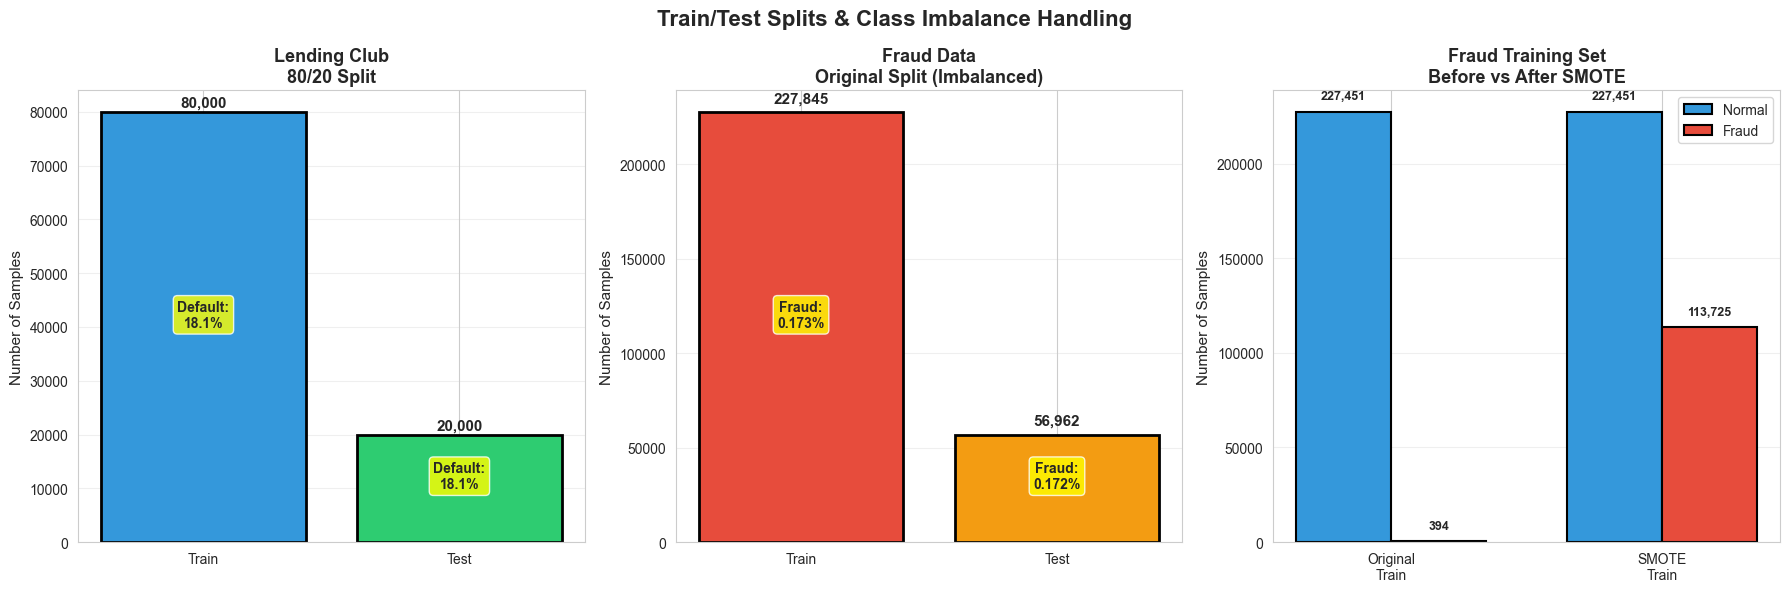

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Train/Test Splits & Class Imbalance Handling',
             fontsize=16, fontweight='bold')

# Lending Club
if 'loan_status_binary' in lending_scaled.columns:
    axes[0].bar(['Train', 'Test'],
                [len(y_train_lending), len(y_test_lending)],
                color=['#3498db', '#2ecc71'], edgecolor='black', linewidth=2)
    axes[0].set_title('Lending Club\n80/20 Split', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Number of Samples', fontsize=11)
    axes[0].grid(alpha=0.3, axis='y')

    # Add values
    axes[0].text(0, len(y_train_lending) + 1000, f'{len(y_train_lending):,}',
                ha='center', fontweight='bold', fontsize=11)
    axes[0].text(1, len(y_test_lending) + 1000, f'{len(y_test_lending):,}',
                ha='center', fontweight='bold', fontsize=11)

    # Add default rates
    axes[0].text(0, len(y_train_lending) * 0.5,
                f'Default:\n{y_train_lending.mean()*100:.1f}%',
                ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
    axes[0].text(1, len(y_test_lending) * 0.5,
                f'Default:\n{y_test_lending.mean()*100:.1f}%',
                ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# Fraud - Original split
axes[1].bar(['Train', 'Test'],
            [len(y_train_fraud), len(y_test_fraud)],
            color=['#e74c3c', '#f39c12'], edgecolor='black', linewidth=2)
axes[1].set_title('Fraud Data\nOriginal Split (Imbalanced)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Samples', fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

axes[1].text(0, len(y_train_fraud) + 5000, f'{len(y_train_fraud):,}',
            ha='center', fontweight='bold', fontsize=11)
axes[1].text(1, len(y_test_fraud) + 5000, f'{len(y_test_fraud):,}',
            ha='center', fontweight='bold', fontsize=11)

axes[1].text(0, len(y_train_fraud) * 0.5,
            f'Fraud:\n{y_train_fraud.mean()*100:.3f}%',
            ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
axes[1].text(1, len(y_test_fraud) * 0.5,
            f'Fraud:\n{y_test_fraud.mean()*100:.3f}%',
            ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# Fraud - SMOTE comparison
fraud_data_comparison = {
    'Original\nTrain': [train_normal_count, train_fraud_count],
    'SMOTE\nTrain': [balanced_normal_count, balanced_fraud_count]
}

x_pos = np.arange(2)
width = 0.35

bars1 = axes[2].bar(x_pos - width/2,
                    [train_normal_count, balanced_normal_count],
                    width, label='Normal', color='#3498db',
                    edgecolor='black', linewidth=1.5)
bars2 = axes[2].bar(x_pos + width/2,
                    [train_fraud_count, balanced_fraud_count],
                    width, label='Fraud', color='#e74c3c',
                    edgecolor='black', linewidth=1.5)

axes[2].set_title('Fraud Training Set\nBefore vs After SMOTE', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Number of Samples', fontsize=11)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(['Original\nTrain', 'SMOTE\nTrain'])
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3, axis='y')

# Add values
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height + 5000,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
os.makedirs('results/preprocessing', exist_ok=True)
plt.savefig('results/preprocessing/day2_12_train_test_splits.png', dpi=300, bbox_inches='tight')
plt.show()

Data Summary Table

In [74]:
summary_data = {
    'Dataset': ['German Credit', 'Lending Club', 'Credit Card Fraud'],
    'Total Samples': [
        f"{len(german_scaled):,}",
        f"{len(lending_scaled):,}",
        f"{len(fraud_scaled):,}"
    ],
    'Train Samples': [
        'N/A (clustering)',
        f"{len(X_train_lending):,}" if 'X_train_lending' in locals() else 'N/A',
        f"{len(X_train_fraud):,}"
    ],
    'Test Samples': [
        'N/A',
        f"{len(X_test_lending):,}" if 'X_test_lending' in locals() else 'N/A',
        f"{len(X_test_fraud):,}"
    ],
    'Features': [
        len(german_scaled.columns),
        len(X_lending.columns) if 'X_lending' in locals() else len(lending_scaled.columns) - 1,
        len(X_fraud.columns)
    ],
    'Target': [
        'None',
        'loan_status_binary',
        'Class'
    ],
    'Use Case': [
        'K-Means Clustering',
        'Credit Risk Prediction',
        'Fraud Detection'
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n📊 Final Dataset Overview:\n")
print(summary_df.to_string(index=False))


📊 Final Dataset Overview:

          Dataset Total Samples    Train Samples Test Samples  Features             Target               Use Case
    German Credit         1,000 N/A (clustering)          N/A        33               None     K-Means Clustering
     Lending Club       100,000           80,000       20,000        52 loan_status_binary Credit Risk Prediction
Credit Card Fraud       284,807          227,845       56,962        44              Class        Fraud Detection
